# Clean Visuals: OPRO Score Evolution (Row 2 only)

A pared-down version of `general_rollout.ipynb`'s Visual 1, restricted to just
the middle row (mean running-max score vs. tokens spent), across the current
6 task columns from `experiments/generate_experiment_args.py` /
`experiments/launch_exps.sh` -- CloudCast, CantBeLate, TSP, HarmBench,
Prompt (GSM8K), Prompt (DROP). `kernelbench` has no runs under
`general_rollout/` anymore (superseded by `tsp` as the 6th task) and is
dropped; GEPA/OpenEvolve are excluded entirely (OPRO-only, per the user).

## Scope notes

- **OPRO-only, 12 canonical variants** (3 sampling strategies x 4 mutators),
  i.e. `noise=0.0` only. `generate_experiment_args.py` now also sweeps
  `noise` over `[0, 0.05, 0.1, 0.25]` for OPRO (48 run-dirs/task on disk,
  not 12) -- filtered down to the `noise=0` subset here so "12 variants"
  means what it meant before that axis was added (confirmed with the user).
- **Inference-model pin**: HarmBench and Prompt (both GSM8K and DROP) each
  have multiple inference-model sweeps on disk. Pinned to each task's
  CURRENT default per `generate_experiment_args.py`'s
  `get_default_inference_model_names` -- Prompt -> Llama-3.2-1B-Instruct,
  HarmBench -> OLMo-2-0425-1B-DPO -- NOT the gemma-4B sweep
  `general_rollout.ipynb` pins to. That gemma-4B pin was tried first here
  too (copied from `general_rollout.ipynb`) and turned out to be reading
  the wrong sweep for Prompt (barely-started, 3-6 records/variant, vs.
  Llama-3.2-1B's complete 51/51) -- confirmed with the user, both pins
  fixed to match the current default.
- **Bank-file layout**: every run dir's `long_running_solution_bank.json`
  now sits one level deeper, under a real `placeholder_path/` subdirectory
  (not flat at the run dir's root like `general_rollout.ipynb` originally
  assumed) -- `find_bank_path` below checks both layouts.
- **No hardcoded iteration/length cap.** Experiments are still running (see
  the coverage report below -- record counts vary a lot run to run, and a
  few variants haven't produced a bank file yet at all). Rather than
  truncating to a fixed `num_iter`, this notebook just reads whatever's
  currently on disk each time it runs, and the token grid extends to the
  *furthest-along* variant (not the shortest) -- `step_interpolate` forward-
  fills a shorter variant's best-so-far past its own last eval, so re-running
  this notebook after more iterations land just naturally extends the plot,
  no code changes needed.

In [1]:
"""Loader for general_rollout run dirs -> ordered (by tokens spent) solution
history. OPRO-only, noise=0 subset (see scope notes above)."""

from __future__ import annotations

import glob
import os

EXPERIMENT_DIR = '../general_rollout'

# Tasks encoded in each run dir name as '..._{task}_...'; 'prompt' further
# splits into two columns by its trailing benchmark suffix (gsm8k/drop).
# 'kernelbench' dropped -- no run dirs left on disk (superseded by 'tsp').
TASKS = ['cloudcast', 'cantbelate', 'tsp', 'harmbench', 'prompt']

# Bounded-substring vocab (see general_rollout.ipynb's parse_run_dir) --
# 'GEPA' must be tried before 'GA' since 'GA' is a substring of 'GEPA'.
MUTATORS = ['kincontext', 'GEPA', 'DE', 'GA']
SAMPLING_STRATEGIES = ['highest_scoring', 'tournament', 'wheel']

# Inference-model pin: harmbench/prompt each hold multiple inference-model
# sweeps on disk now; pinned to each task's CURRENT default inference model
# per generate_experiment_args.py's get_default_inference_model_names
# (prompt -> Llama-3.2-1B-Instruct, harmbench -> OLMo-2-0425-1B-DPO), not
# the older gemma-4B sweep general_rollout.ipynb pins to -- confirmed with
# the user after the gemma-4B pin was found to be reading prompt_gsm8k's
# barely-started sweep (3-6 records/variant) instead of its complete
# Llama-3.2-1B one (51/51); harmbench's gemma-4B sweep is further along
# (51/51 for most variants) than OLMo-2-DPO's (15-16/51) but no longer
# matches the task's current default, so it's repinned too for consistency.
# cloudcast/cantbelate/tsp only ever had a gemma-4B variant, so no filter
# needed there.
TASK_INFERENCE_MODEL_FILTER: dict[str, str] = {
    'prompt': 'meta-llamaLlama-32-1B-Instruct',
    'harmbench': 'allenaiOLMo-2-0425-1B-DPO',
}


def inference_model_ok(dirname: str, task_token: str) -> bool:
    inference_model = TASK_INFERENCE_MODEL_FILTER.get(task_token)
    return inference_model is None or f'_{inference_model}_' in dirname


def noise_token(dirname: str) -> str:
    """Raw noise value as it appears in the dirname (e.g. '00', '005').

    main.py builds the dirname by joining every CLI arg value in argparse
    definition order (str(val).replace('.', '').replace('/', '')); noise
    directly follows pruning_strategy, which get_args_for_roll_outs always
    sets to the literal 'lowest_scoring' -- so the token right after that
    literal is noise, regardless of every other arg's value.
    """
    return dirname.split('lowest_scoring_', 1)[1].split('_', 1)[0]


def parse_run_dir(dirname: str) -> tuple[str, str, str, str]:
    """(task_name, column_key, mutator, sampling_strategy)."""
    task_name = next(t for t in TASKS if f'_{t}_' in dirname)
    column_key = task_name
    if task_name == 'prompt':
        benchmark = dirname.rsplit('_', 1)[-1]  # 'drop' or 'gsm8k'
        column_key = f'prompt_{benchmark}'
    mutator = next(m for m in MUTATORS if f'_{m}_' in dirname)
    sampling_strategy = next(s for s in SAMPLING_STRATEGIES if f'_{s}_' in dirname)
    return task_name, column_key, mutator, sampling_strategy


def find_bank_path(run_dir: str) -> str | None:
    """long_running_solution_bank.json for a run dir, whichever layout era
    it's from: flat at the run dir's root, or nested one level under a real
    placeholder_path/ subdirectory (current layout for every run on disk as
    of this notebook). None if the run hasn't produced a bank file yet.
    """
    direct = os.path.join(run_dir, 'long_running_solution_bank.json')
    if os.path.exists(direct):
        return direct
    nested = glob.glob(os.path.join(run_dir, '*', 'long_running_solution_bank.json'))
    return nested[0] if nested else None


def load_bank(path: str) -> list[dict]:
    """Read a solution_bank.json, ordered ascending by id == tokens spent."""
    import json
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    return [data[str(k)] for k in sorted(int(k) for k in data)]


# TSP correctness gap (confirmed with the user): llm_optimizer/tasks/
# traveling_salesman.py's evaluate_distance/extract_string never checks
# that a submitted <trace> visits all TSP_NUM_POINTS cities exactly once
# -- a trace that skips/repeats cities still gets scored (sum of whatever
# consecutive distances it does list), which can come out BETTER than the
# instance's true optimum since skipping cities can produce an
# artificially short "tour". Verified: every general_rollout/ tsp run uses
# main.py's untouched defaults (num_points=100, num_decimals=3, seed=0),
# so they're all solving the exact same instance, whose proven optimum
# (re-solved with the same exact ortools CP-SAT AddCircuit solver
# traveling_salesman.py itself uses, status=OPTIMAL) is -1651.054 -- yet
# 6/9648 records on disk score better than that, all with malformed
# traces (wrong length and/or duplicate city indices). A single one of
# these permanently corrupts a variant's running-max forever after, so
# is_valid_tsp_trace is applied at load time (both discovery cells below)
# rather than left for the plots to work around.
TSP_NUM_POINTS = 100
TSP_TRUE_OPTIMUM = -1651.054


def is_valid_tsp_trace(solution: str) -> bool:
    """True iff `solution` is a well-formed <trace> visiting all
    TSP_NUM_POINTS cities exactly once."""
    if '<trace>' not in solution or '</trace>' not in solution:
        return False
    inner = solution[
        solution.index('<trace>') + len('<trace>') : solution.index('</trace>')
    ]
    try:
        points = [int(p.strip()) for p in inner.split(',') if p.strip()]
    except ValueError:
        return False
    return sorted(points) == list(range(TSP_NUM_POINTS))


def filter_tsp_records(dirname: str, task_name: str, records: list[dict]) -> list[dict]:
    """Drop malformed-trace records for TSP (see note above); no-op for
    every other task."""
    if task_name != 'tsp':
        return records
    valid = [r for r in records if is_valid_tsp_trace(r['solution'])]
    n_dropped = len(records) - len(valid)
    if n_dropped:
        print(f'[tsp] dropped {n_dropped} invalid-trace record(s) from {dirname}')
    return valid


In [2]:
"""Discover OPRO/noise=0 run dirs, load them, group by column x variant.

No length/iteration truncation (see scope notes above) -- loads exactly
what's on disk right now. Prints a coverage report so it's obvious at a
glance which of the 12 canonical variants are still missing/incomplete for
a given column when this is re-run mid-experiment.
"""

OPRO_MUTATORS_CANON = ['kincontext', 'DE', 'GA', 'GEPA']
OPRO_STRATEGIES_CANON = ['highest_scoring', 'tournament', 'wheel']
OPRO_VARIANT_ORDER = [
    f'opro_{mutator}_{strategy}'
    for strategy in OPRO_STRATEGIES_CANON
    for mutator in OPRO_MUTATORS_CANON
]

runs_by_column: dict[str, dict[str, list[dict]]] = {}
skipped_no_bank: dict[str, list[str]] = {}

for dirname in sorted(os.listdir(EXPERIMENT_DIR)):
    run_dir = os.path.join(EXPERIMENT_DIR, dirname)
    if not os.path.isdir(run_dir) or not dirname.startswith('opro_'):
        continue
    if noise_token(dirname) != '00':
        continue
    task_name, column_key, mutator, sampling_strategy = parse_run_dir(dirname)
    if not inference_model_ok(dirname, task_name):
        continue

    optimizer_label = f'opro_{mutator}_{sampling_strategy}'
    bank_path = find_bank_path(run_dir)
    if bank_path is None:
        # Job hasn't produced a bank file yet -- skip rather than crash;
        # re-running this notebook later will pick it up once it exists.
        skipped_no_bank.setdefault(column_key, []).append(optimizer_label)
        continue

    records = load_bank(bank_path)
    records = filter_tsp_records(dirname, task_name, records)
    if not records:
        continue
    runs_by_column.setdefault(column_key, {})[optimizer_label] = records

print(f'{len(runs_by_column)} columns loaded:')
for column_key, variants in sorted(runs_by_column.items()):
    lens = sorted(len(r) for r in variants.values())
    missing = sorted(set(OPRO_VARIANT_ORDER) - set(variants))
    missing += skipped_no_bank.get(column_key, [])
    print(
        f'  {column_key:14s} {len(variants):2d}/12 variants  '
        f'record counts {lens[0]}-{lens[-1]}'
        + (f'  MISSING: {sorted(set(missing))}' if missing else ''),
    )


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 6 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 7 invalid-trace record(s) from opro_gemini-37-flash_GA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_GA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 8 invalid-trace record(s) from opro_gemini-37-flash_GEPA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
6 columns loaded:
  cantbelate     12/12 variants  record counts 201-201
  cloudcast      12/12 variants  record counts 76-201
  harmbench      12/12 variants  record counts 51-51
  prompt_drop    12/12 variants  record counts 51-51
  prompt_gs

## Score evolution vs. tokens spent (mean running-max, OPRO-only)

One panel per column: every OPRO variant's own running-max ("best found so
far") trajectory drawn thin/faint in its usual blue-ramp shade, plus one
bold dark mean-of-12 line -- exactly Visual 1 row 2's metric from
`general_rollout.ipynb`, restricted to the 12 OPRO variants (no GEPA/
OpenEvolve, no seed-population overlays).

In [3]:
"""Palette + shared plotting helpers."""

import itertools

import matplotlib.pyplot as plt
import numpy as np

# --- Chart chrome (dataviz skill references/palette.md, light mode) ---
SURFACE = '#fcfcfb'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'

# --- Accent for the TSP true-optimum reference line (see TSP_TRUE_OPTIMUM
# in the loader cell above) -- distinct from the blue OPRO-variant ramp
# and the black mean line so it reads as "a fixed target", not a 13th run. ---
REFERENCE_LINE_COLOR = '#eb6834'

# --- Sequential blue ramp, 12 steps, one per OPRO variant, fixed canonical
# order so a given (mutator, sampling_strategy) always gets the same shade
# across every column ("color follows the entity") ---
BLUE_RAMP = [
    '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7', '#3987e5',
    '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b',
]
OPRO_COLOR_BY_LABEL = dict(zip(OPRO_VARIANT_ORDER, BLUE_RAMP, strict=True))


def color_for(optimizer_label: str) -> str:
    return OPRO_COLOR_BY_LABEL[optimizer_label]


# --- Column order + display titles ---
COLUMN_ORDER = [
    'cloudcast', 'cantbelate', 'tsp',
    'harmbench', 'prompt_gsm8k', 'prompt_drop',
]
COLUMN_TITLES = {
    'cloudcast': 'CloudCast',
    'cantbelate': 'CantBeLate',
    'tsp': 'TSP',
    'harmbench': 'HarmBench',
    'prompt_gsm8k': 'Prompt (GSM8K)',
    'prompt_drop': 'Prompt (DROP)',
}


def running_max(values: np.ndarray) -> np.ndarray:
    """Best score found so far, at each step."""
    return np.maximum.accumulate(values)


def step_interpolate(xs: np.ndarray, ys: np.ndarray, grid: np.ndarray) -> np.ndarray:
    """Forward-fill ys(xs) onto grid: value as of the last eval at/before g.

    NaN before xs[0] (no eval yet at that token count). Grid points AFTER
    xs[-1] hold ys[-1] flat (idx clips to len(ys)-1) -- so a variant that
    hasn't spent as many tokens yet still correctly reports its best-so-far
    score at later grid points, letting the mean line run exactly as far as
    the longest (furthest-along) variant, not the shortest.
    """
    idx = np.searchsorted(xs, grid, side='right') - 1
    out = np.where(idx >= 0, ys[np.clip(idx, 0, len(ys) - 1)], np.nan)
    return out


def tokens_fmt(x: float, _pos: int | None = None) -> str:
    if x >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    if x >= 1_000:
        return f'{x / 1_000:.0f}k'
    return f'{x:.0f}'


# --- TSP score is -distance (see TSP_TRUE_OPTIMUM in the loader cell
# above). Every variant shares the exact same seed distance (11324.186)
# at t=0 -- not a per-variant "stuck" outlier, an identical constant
# across all 48 (mutator x sampling x noise) variants -- and by ~20k
# tokens every one of them has escaped into a tight band (verified against
# the data on disk: transient running-max stays within [1735, 2190] for
# all t >= 20k across all 48 variants; final converged values land in
# [1665, 1999], true optimum 1651). Plotted on a log, inverted axis
# ("up" = improving, consistent with every other panel) so the shared
# seed-to-~2000 drop doesn't need its own decade of vertical space --
# TSP_YLIM_DIST then zooms into the band where variants actually differ.
# This *is* a hard clip (like the old ZOOM_YLIM), but a safe one right
# now: it only crops the seed spike every variant shares identically, not
# any variant's real converged tail -- if a future rerun produces a
# variant that doesn't converge into this band, its line will simply run
# off the panel edge rather than this bound auto-adjusting, so revisit
# these numbers if that happens.
TSP_YLABEL = 'distance (log scale, lower = better)'
TSP_YLIM_DIST = (1600, 2300)  # (near-optimal edge, worst-converged edge)


def tsp_style(ax: plt.Axes) -> None:
    ax.set_yscale('log')
    # bottom=larger/worse distance, top=smaller/better -- achieves the
    # "up = improving" inversion directly, no separate invert_yaxis() call.
    ax.set_ylim(TSP_YLIM_DIST[1], TSP_YLIM_DIST[0])


saved to ../figs/clean_visual1_row2_opro_only.pdf


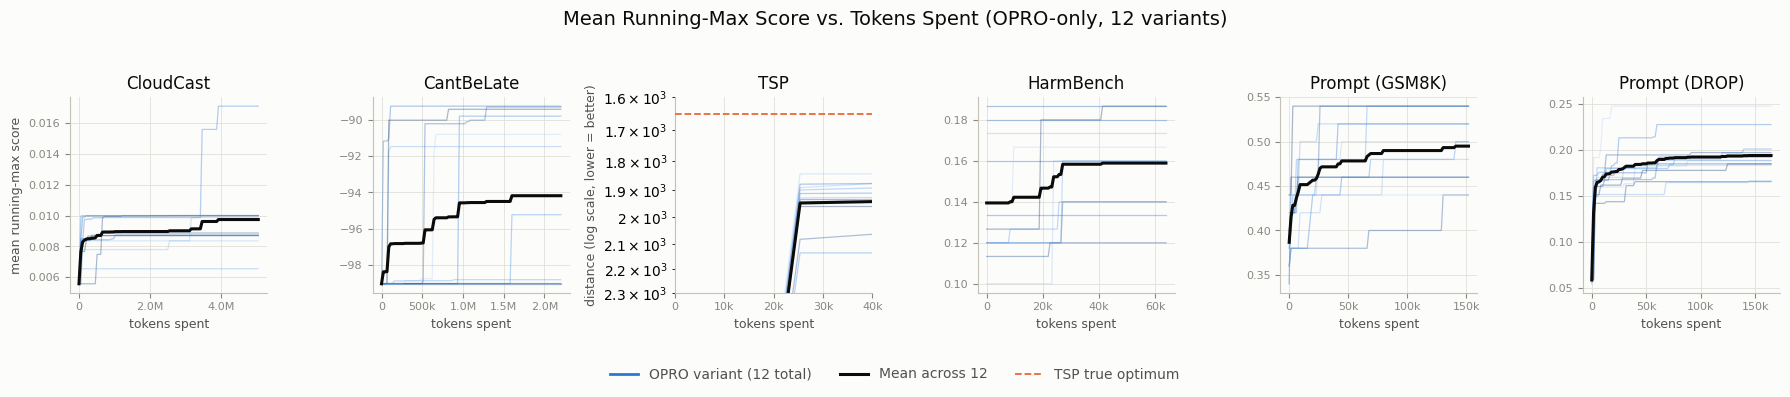

In [4]:
"""Build the 1x6 figure: mean running-max score vs. tokens spent, OPRO-only."""

# TSP's own token extent runs out to ~2.5M, but almost all of its
# convergence happens well before that -- zoom that column in on its own
# (every other column keeps its full autoscaled range).
# All 48 TSP variants converge into their final band by ~20-30k
# tokens (verified against the data on disk); 100k left the last
# 60-70% of the panel as flat tail, so tightened to 40k.
ZOOM_XLIM = {'tsp': (0, 40_000)}

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)

    variants = runs_by_column.get(column_key, {})
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)
    if not variants:
        # Task hasn't produced any usable bank files yet -- leave the panel
        # blank rather than crashing; re-running later will fill it in.
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    trajectories = {
        label: (
            np.array([r['cumulative_tokens_spent'] for r in records], dtype=float),
            running_max(np.array([r['score'] for r in records], dtype=float)),
        )
        for label, records in variants.items()
    }

    # Grid extends to the FURTHEST-along variant (max, not min) -- see
    # step_interpolate's docstring for why that's honest, not fabricated,
    # and lets this panel keep extending on its own as more iterations land.
    grid_end = max(tokens.max() for tokens, _ in trajectories.values())
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    # TSP is plotted as distance (-score) on a log axis instead of raw
    # score (see tsp_style/TSP_YLABEL in the helpers cell above) --
    # everything else (running_max, step_interpolate, the mean line) still
    # operates on score exactly as before; only the values actually handed
    # to ax.plot get sign-flipped for this one column.
    sign = -1.0 if column_key == 'tsp' else 1.0

    interpolated = []
    for label, (tokens, cummax) in trajectories.items():
        resampled = step_interpolate(tokens, cummax, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, sign * resampled, color=color_for(label), linewidth=0.9,
            alpha=0.35, zorder=2,
        )

    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, sign * mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO variant (12 total)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across 12'),
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=3,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.15),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent (OPRO-only, 12 variants)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

FIGS_DIR = '../figs'
os.makedirs(FIGS_DIR, exist_ok=True)
fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_only.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "clean_visual1_row2_opro_only.pdf")}')

plt.show()


## Score evolution vs. tokens spent, by noise value (OPRO-only)

Same 1x6 grid/columns/metric as above, but instead of collapsing to the
`noise=0` subset, includes all 4 noise values OPRO sweeps (`0`, `0.05`,
`0.1`, `0.25`). For each column: one mean-running-max-vs-tokens line per
noise value (mean across that noise value's own 12 mutator x sampling-
strategy variants), colored along a sequential colormap by noise value.
No individual per-variant lines here -- 4 noise groups x 12 variants = 48
per panel was too dense against just the 4 lines that actually matter for
this comparison (confirmed with the user).

In [5]:
"""Discover OPRO run dirs across ALL 4 noise values, grouped by
column x noise_value x variant. Reuses parse_run_dir / noise_token /
find_bank_path / load_bank / inference_model_ok / filter_tsp_records from
the loader cell above -- same inference-model pins, same nested-bank-path
handling, same invalid-TSP-trace filtering, same "skip what's not on disk
yet" behavior, just without the noise=0 filter.
"""

NOISE_TOKEN_TO_VALUE = {'00': 0.0, '005': 0.05, '01': 0.1, '025': 0.25}

runs_by_column_noise: dict[str, dict[float, dict[str, list[dict]]]] = {}

for dirname in sorted(os.listdir(EXPERIMENT_DIR)):
    run_dir = os.path.join(EXPERIMENT_DIR, dirname)
    if not os.path.isdir(run_dir) or not dirname.startswith('opro_'):
        continue
    noise_value = NOISE_TOKEN_TO_VALUE.get(noise_token(dirname))
    if noise_value is None:
        continue  # unexpected noise token -- skip rather than crash
    task_name, column_key, mutator, sampling_strategy = parse_run_dir(dirname)
    if not inference_model_ok(dirname, task_name):
        continue

    optimizer_label = f'opro_{mutator}_{sampling_strategy}'
    bank_path = find_bank_path(run_dir)
    if bank_path is None:
        continue  # job hasn't produced a bank file yet
    records = load_bank(bank_path)
    records = filter_tsp_records(dirname, task_name, records)
    if not records:
        continue

    runs_by_column_noise.setdefault(column_key, {}).setdefault(
        noise_value, {},
    )[optimizer_label] = records

print(f'{len(runs_by_column_noise)} columns loaded:')
for column_key, by_noise in sorted(runs_by_column_noise.items()):
    coverage = ', '.join(
        f'noise={n}: {len(v):2d}/12' for n, v in sorted(by_noise.items())
    )
    print(f'  {column_key:14s} {coverage}')


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_DE_tournament_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_DE_wheel_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_005_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 6 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_01_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 5 invalid-trace record(s) from opro_gemini-37-flash_GA_tournament_05_5_-1_15_lowest_scoring_005_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 7 invalid-trace record(s) from opro_gemini-37-flash_GA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 5 invalid-trace record(s) from opro_gemini-37-flash_GA_tournament_05_5_-1_15_lowest_scoring_01_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 5 invalid-trace record(s) from opro_gemini-37-flash_GA_tournament_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 8 invalid-trace record(s) from opro_gemini-37-flash_GA_whe

[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_005_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_tournament_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 8 invalid-trace record(s) from opro_gemini-37-flash_GEPA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 5 invalid-trace record(s) from opro_gemini-37-flash_GEPA_wheel_05_5_-1_15_lowest_scoring_01_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_005_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_01_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from o

[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_01_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


6 columns loaded:
  cantbelate     noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  cloudcast      noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  harmbench      noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  prompt_drop    noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  prompt_gsm8k   noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  tsp            noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12


saved to ../figs/clean_visual1_row2_opro_by_noise.pdf


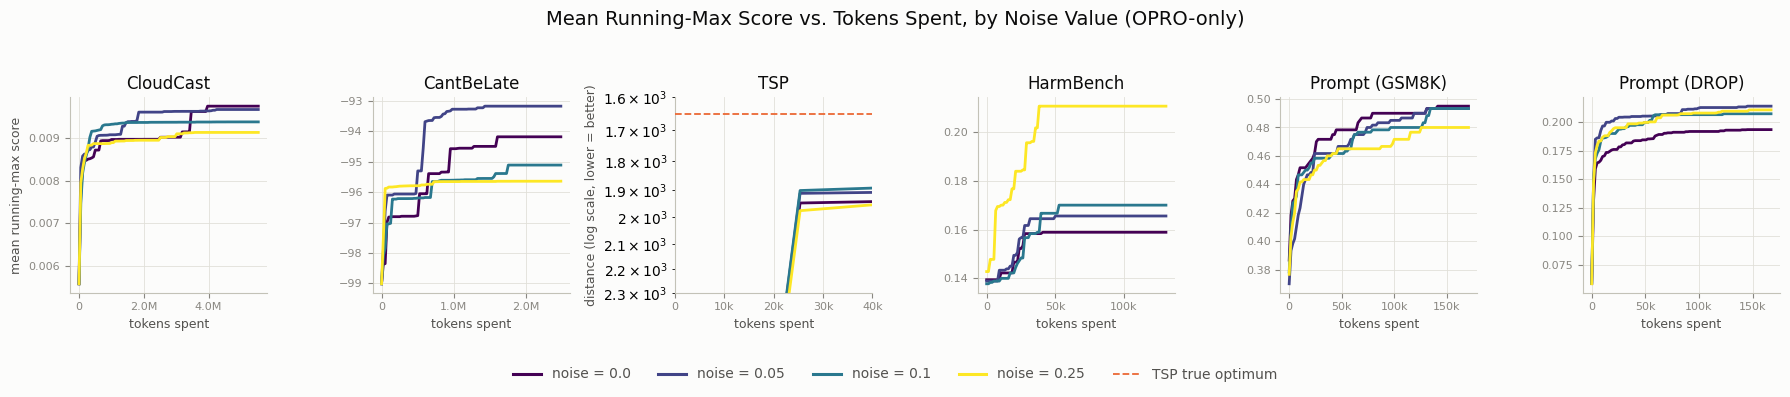

In [6]:
"""Build the 1x6 figure: mean running-max score vs. tokens spent,
OPRO-only, one mean line per noise value (colored by noise), no
per-variant lines (see markdown cell above)."""

NOISE_VALUES = [0.0, 0.05, 0.1, 0.25]
NOISE_CMAP = plt.get_cmap('viridis')
NOISE_NORM = plt.Normalize(vmin=min(NOISE_VALUES), vmax=max(NOISE_VALUES))


def color_for_noise(noise_value: float):
    return NOISE_CMAP(NOISE_NORM(noise_value))


fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    by_noise = runs_by_column_noise.get(column_key, {})
    if not by_noise:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    # One shared grid per column, across every noise group's own variants,
    # extended to the furthest-along point overall -- same "extend to the
    # longest, not the shortest" reasoning as the noise=0 figure above, so
    # all 4 mean lines are drawn on one consistent x range per panel and
    # re-running this after more iterations land just extends it further.
    grid_end = max(
        r['cumulative_tokens_spent']
        for variants in by_noise.values()
        for records in variants.values()
        for r in records
    )
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    # TSP plotted as distance (-score) on a log axis -- see tsp_style/
    # TSP_YLABEL in the helpers cell above and the sign comment in the
    # noise=0 score figure above.
    sign = -1.0 if column_key == 'tsp' else 1.0

    for noise_value in NOISE_VALUES:
        variants = by_noise.get(noise_value)
        if not variants:
            continue
        interpolated = []
        for records in variants.values():
            tokens = np.array(
                [r['cumulative_tokens_spent'] for r in records], dtype=float,
            )
            cummax = running_max(
                np.array([r['score'] for r in records], dtype=float),
            )
            interpolated.append(step_interpolate(tokens, cummax, grid))
        mean_series = np.nanmean(np.vstack(interpolated), axis=0)
        ax.plot(
            grid, sign * mean_series, color=color_for_noise(noise_value),
            linewidth=2.0, zorder=3,
        )

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=color_for_noise(n), lw=2.2, label=f'noise = {n}')
    for n in NOISE_VALUES
] + [
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=5,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.15),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, by Noise Value (OPRO-only)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_by_noise.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "clean_visual1_row2_opro_by_noise.pdf")}')

plt.show()


## Semantic diversity vs. tokens spent (windowed, OPRO-only)

Same shape as the first (noise=0) visual above -- same 12 canonical OPRO
variants, thin per-variant line + one bold dark mean line per column -- but
**y is windowed semantic diversity instead of score**: average pairwise
cosine *distance* across the last 5 chronologically-discovered solutions
(sliding window, not the live population), same metric as
`general_rollout.ipynb`'s Visual 2 / Fig A. Plotted as the **raw**
trajectory (no running-max transform) since diversity has no "higher is
strictly better, take the best-so-far" framing the way score does.

**Embedding model, same task-pairing as Fig A**: code tasks (CloudCast,
CantBeLate) -> `Qodo/Qodo-Embed-1-1.5B`; text tasks (HarmBench, Prompt
GSM8K/DROP) -> `all-MiniLM-L6-v2`. TSP wasn't part of `general_rollout.ipynb`
(didn't exist yet) so isn't in that pairing -- its solutions are raw tour
traces like `<trace>3,7,83,...</trace>`, not code, so it's grouped with the
text/`all-MiniLM-L6-v2` bucket (confirmed with the user).

**Fresh cache, not `../embedding_cache/`'s existing CantBeLate/CloudCast
files**: those `*__Qodo__Qodo-Embed-1-1.5B.pkl` files are from an earlier
run of these tasks -- checked against the current solution texts loaded
above, only ~1/2348 (CantBeLate) and ~1/1562 (CloudCast) unique texts
actually hit that cache, so it's stale rather than reusable. This cell
writes to `../embedding_cache/clean_visuals/` instead (a separate
subdirectory) so it doesn't get merged into / confused with that stale
cache, and every column's cache lives in one consistent place going
forward.

**Not executed in this sandbox**: no GPU here (`torch.cuda.is_available()`
is `False`), and CantBeLate + CloudCast alone need ~3,900 fresh
Qodo-Embed-1.5B (1.5B-param) embeddings -- CPU-only would be slow. The
HarmBench/Prompt/TSP side (`all-MiniLM-L6-v2`) is cheap/CPU-fine regardless.
Run this cell (and the two after it) yourself, ideally on a GPU node.

In [7]:
"""Embedding cache loader + windowed semantic-diversity helper (see
markdown cell above for the task/model pairing and why this writes to a
fresh cache subdirectory instead of ../embedding_cache/'s existing
CantBeLate/CloudCast files)."""

import pickle

import torch
from sentence_transformers import SentenceTransformer

CODE_TASKS = {'cloudcast', 'cantbelate'}
CODE_EMBED_MODEL = 'Qodo/Qodo-Embed-1-1.5B'
TEXT_EMBED_MODEL = 'all-MiniLM-L6-v2'
EMBEDDING_CACHE_DIR = '../embedding_cache/clean_visuals'
DIVERSITY_WINDOW = 5
EMBED_MAX_SEQ_LENGTH = 4096  # see get_or_build_embeddings docstring

EMBED_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


def task_for_column(column_key: str) -> str:
    """column_key -> task_name (undoes the prompt_gsm8k/prompt_drop split)."""
    return 'prompt' if column_key.startswith('prompt_') else column_key


def embed_model_for(column_key: str) -> str:
    """Code embedding model for code tasks, sentence model for everything
    else (text tasks, and TSP -- see markdown cell above)."""
    return CODE_EMBED_MODEL if task_for_column(column_key) in CODE_TASKS else TEXT_EMBED_MODEL


def cache_path_for(column_key: str, model_name: str) -> str:
    filename = f"{column_key}__{model_name.replace('/', '__')}.pkl"
    return os.path.join(EMBEDDING_CACHE_DIR, filename)


def get_or_build_embeddings(
    column_key: str,
    texts: set[str],
    chunk_size: int = 64,
    batch_size: int = 8,
) -> dict[str, np.ndarray]:
    """Load cached embeddings for `texts`, computing + caching what's missing.

    Encodes in small chunks, saving the cache to disk after each one, so a
    future crash/interrupt only loses the in-flight chunk. fp16 only on
    CUDA (halves memory, needed since Qodo-Embed's code snippets run up to
    a few thousand tokens without flash_attn installed here) -- fp16 on
    CPU doesn't help and can be slower/unsupported for some ops, so CPU
    runs stay fp32. Sorting missing texts shortest-first means a batch
    never randomly clusters several of the longest sequences together
    (the worst case for a memory spike).
    """
    model_name = embed_model_for(column_key)
    cache_path = cache_path_for(column_key, model_name)
    os.makedirs(EMBEDDING_CACHE_DIR, exist_ok=True)

    cache: dict[str, np.ndarray] = {}
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            cache = pickle.load(f)

    missing = sorted(texts - cache.keys(), key=len)
    if not missing:
        print(f'[{column_key}] {len(texts)} texts, all cached.')
        return cache

    print(
        f'[{column_key}] embedding {len(missing)} new / {len(texts)} '
        f'total texts with {model_name} on {EMBED_DEVICE}...',
    )
    model_kwargs = {'torch_dtype': torch.float16} if EMBED_DEVICE == 'cuda' else {}
    model = SentenceTransformer(model_name, device=EMBED_DEVICE, model_kwargs=model_kwargs)
    model.max_seq_length = min(model.max_seq_length, EMBED_MAX_SEQ_LENGTH)

    for start in range(0, len(missing), chunk_size):
        chunk = missing[start : start + chunk_size]
        new_embeddings = model.encode(
            chunk, batch_size=batch_size, show_progress_bar=False,
            convert_to_numpy=True,
        )
        cache.update(zip(chunk, new_embeddings, strict=True))
        with open(cache_path, 'wb') as f:
            pickle.dump(cache, f)
        print(
            f'  [{column_key}] {min(start + chunk_size, len(missing))}'
            f'/{len(missing)} embedded and saved',
        )

    del model
    if EMBED_DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return cache


def windowed_diversity(
    texts: list[str],
    embeddings: dict[str, np.ndarray],
    window: int = DIVERSITY_WINDOW,
) -> np.ndarray:
    """Average pairwise cosine distance across the last `window` solutions.

    Returns an array aligned to texts[window - 1:] -- shorter than `texts`
    itself, since there's no diversity value until `window` solutions
    exist. Empty (not an error) if `texts` itself has fewer than `window`
    entries -- e.g. a TSP variant whose invalid-trace records got filtered
    out (see filter_tsp_records above) down to a handful of real solutions;
    callers should skip a variant entirely when this happens rather than
    plot an all-empty trajectory (see the computation cells below). Duplicate
    solution text is left in deliberately (same no-dedup stance as the
    score visuals above): a duplicate in the window contributes a real
    0-distance pair, honest signal about how much of the window is
    actually novel.
    """
    if len(texts) < window:
        return np.empty(0, dtype=float)

    vecs = np.stack([embeddings[t] for t in texts])
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    unit = vecs / np.where(norms == 0, 1, norms)

    pair_mask = ~np.eye(window, dtype=bool)
    diversity = np.empty(len(texts) - window + 1)
    for out_idx, i in enumerate(range(window - 1, len(texts))):
        w = unit[i - window + 1 : i + 1]
        sims = w @ w.T
        diversity[out_idx] = 1.0 - sims[pair_mask].mean()
    return diversity


In [8]:
"""Compute windowed diversity trajectories per (column, OPRO variant).

Reuses `runs_by_column` from the discovery cell near the top of this
notebook (OPRO-only, noise=0, 12-variant subset) -- no separate loader
needed, this is the exact same run set the first visual plots, just with
diversity instead of score computed over it.
"""

diversity_by_column: dict[str, dict[str, tuple[np.ndarray, np.ndarray]]] = {}

for column_key, variants in runs_by_column.items():
    all_texts = {r['solution'] for records in variants.values() for r in records}
    embeddings = get_or_build_embeddings(column_key, all_texts)

    per_optimizer = {}
    for label, records in variants.items():
        texts = [r['solution'] for r in records]
        diversity = windowed_diversity(texts, embeddings)
        if len(diversity) == 0:
            # Fewer than DIVERSITY_WINDOW real records (e.g. a TSP variant
            # gutted by filter_tsp_records) -- no windowed-diversity value
            # exists yet, skip rather than plot an empty trajectory.
            print(
                f'[{column_key}] skipping {label}: only {len(texts)} '
                f'record(s), need >= {DIVERSITY_WINDOW}',
            )
            continue
        tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
        per_optimizer[label] = (tokens[DIVERSITY_WINDOW - 1 :], diversity)
    diversity_by_column[column_key] = per_optimizer

print('diversity trajectories computed for:')
for column_key, per_optimizer in sorted(diversity_by_column.items()):
    if not per_optimizer:
        print(f'  {column_key:14s} 0/12 variants (all too short)')
        continue
    lengths = [len(d) for _, d in per_optimizer.values()]
    print(
        f'  {column_key:14s} {len(per_optimizer):2d}/12 variants, '
        f'trajectory length {min(lengths)}-{max(lengths)}',
    )


[prompt_drop] 596 texts, all cached.
[prompt_gsm8k] 578 texts, all cached.
[cantbelate] 2348 texts, all cached.


[cloudcast] 2034 texts, all cached.


[tsp] 910 texts, all cached.
[harmbench] 581 texts, all cached.


diversity trajectories computed for:
  cantbelate     12/12 variants, trajectory length 197-197
  cloudcast      12/12 variants, trajectory length 72-197
  harmbench      12/12 variants, trajectory length 47-47
  prompt_drop    12/12 variants, trajectory length 47-47
  prompt_gsm8k   12/12 variants, trajectory length 47-47
  tsp            12/12 variants, trajectory length 139-197


/scratch/mansisak/tmp/ipykernel_571574/2411821845.py:37: RuntimeWarning: Mean of empty slice
  mean_series = np.nanmean(np.vstack(interpolated), axis=0)


saved to ../figs/clean_visual2_diversity_opro_only.pdf


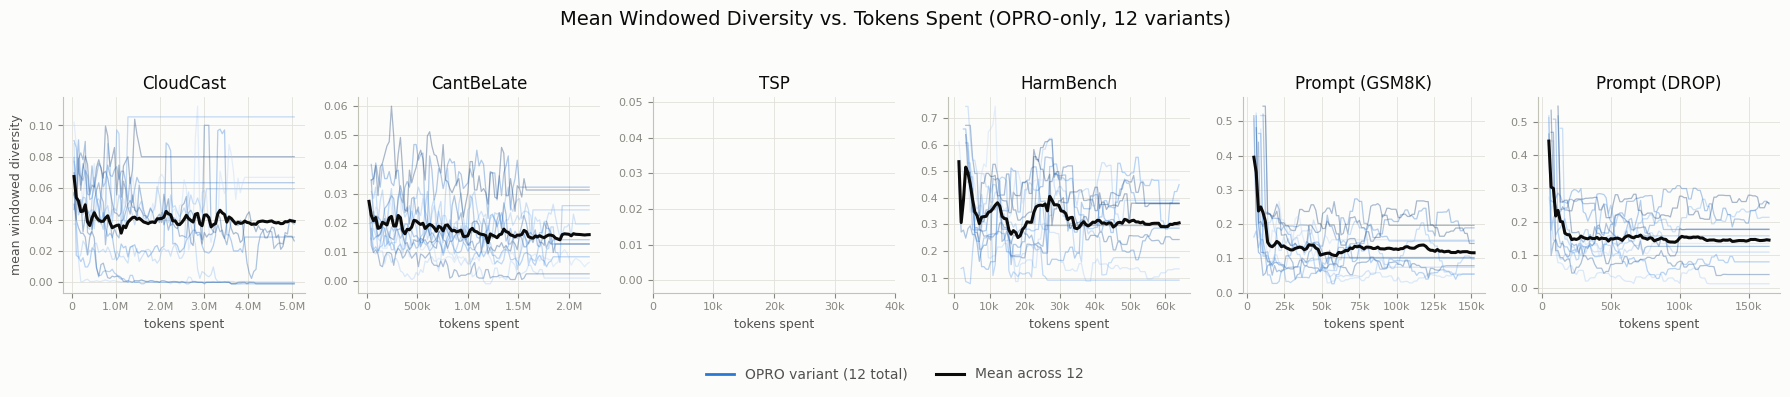

In [9]:
"""Build the 1x6 figure: mean windowed diversity vs. tokens spent,
OPRO-only. Same layout/style as the noise=0 score figure above, just
diversity instead of score and no running-max transform (raw trajectory,
per the markdown cell above)."""

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)

    per_optimizer = diversity_by_column.get(column_key, {})
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)
    if not per_optimizer:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    # Grid extends to the FURTHEST-along variant (max, not min) -- same
    # "read from disk and update" reasoning as the score figure above.
    grid_end = max(tokens.max() for tokens, _ in per_optimizer.values())
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    interpolated = []
    for label, (tokens, diversity) in per_optimizer.items():
        resampled = step_interpolate(tokens, diversity, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, resampled, color=color_for(label), linewidth=0.9,
            alpha=0.35, zorder=2,
        )

    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean windowed diversity', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO variant (12 total)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across 12'),
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=2,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.15),
)

fig.suptitle(
    'Mean Windowed Diversity vs. Tokens Spent (OPRO-only, 12 variants)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual2_diversity_opro_only.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "clean_visual2_diversity_opro_only.pdf")}')

plt.show()


## Semantic diversity vs. tokens spent, by noise value (OPRO-only)

Same idea as the "by noise value" score visual above, applied to the
diversity metric instead: for each column, one mean-windowed-diversity-vs-
tokens line per noise value (mean across that noise value's own 12
variants), colored along the same viridis ramp by noise value, no
per-variant lines. Reuses `runs_by_column_noise` (loaded once, up top,
alongside the noise=0 subset) and the embedding/diversity helpers from the
cell above -- extends the same `embedding_cache/clean_visuals/` cache
files rather than rebuilding them, so only the noise=0.05/0.1/0.25
variants' new solution texts (not already embedded for the noise=0
diversity visual above) actually need fresh GPU work here.

In [10]:
"""Compute windowed diversity trajectories per (column, noise_value, variant).

Embeds once per column across the UNION of all 4 noise groups' texts (not
once per noise group) so get_or_build_embeddings only has to encode each
distinct solution text once, and so this shares/extends the exact same
cache file the noise=0 diversity visual above already populated.
"""

diversity_by_column_noise: dict[str, dict[float, dict[str, tuple[np.ndarray, np.ndarray]]]] = {}

for column_key, by_noise in runs_by_column_noise.items():
    all_texts = {
        r['solution']
        for variants in by_noise.values()
        for records in variants.values()
        for r in records
    }
    embeddings = get_or_build_embeddings(column_key, all_texts)

    per_noise = {}
    for noise_value, variants in by_noise.items():
        per_optimizer = {}
        for label, records in variants.items():
            texts = [r['solution'] for r in records]
            diversity = windowed_diversity(texts, embeddings)
            if len(diversity) == 0:
                # Fewer than DIVERSITY_WINDOW real records (e.g. a TSP
                # variant gutted by filter_tsp_records) -- skip rather
                # than plot an empty trajectory.
                print(
                    f'[{column_key}] skipping noise={noise_value} {label}: '
                    f'only {len(texts)} record(s), need >= {DIVERSITY_WINDOW}',
                )
                continue
            tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
            per_optimizer[label] = (tokens[DIVERSITY_WINDOW - 1 :], diversity)
        per_noise[noise_value] = per_optimizer
    diversity_by_column_noise[column_key] = per_noise

print('diversity-by-noise trajectories computed for:')
for column_key, per_noise in sorted(diversity_by_column_noise.items()):
    coverage = ', '.join(
        f'noise={n}: {len(v):2d}/12' for n, v in sorted(per_noise.items())
    )
    print(f'  {column_key:14s} {coverage}')


[prompt_drop] 2349 texts, all cached.
[prompt_gsm8k] 2281 texts, all cached.


[cantbelate] 9329 texts, all cached.


[cloudcast] 8047 texts, all cached.


[tsp] 3525 texts, all cached.


[harmbench] 2315 texts, all cached.
diversity-by-noise trajectories computed for:
  cantbelate     noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  cloudcast      noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  harmbench      noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  prompt_drop    noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  prompt_gsm8k   noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  tsp            noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12


/scratch/mansisak/tmp/ipykernel_571574/239057400.py:41: RuntimeWarning: Mean of empty slice
  mean_series = np.nanmean(np.vstack(interpolated), axis=0)


saved to ../figs/clean_visual2_diversity_by_noise.pdf


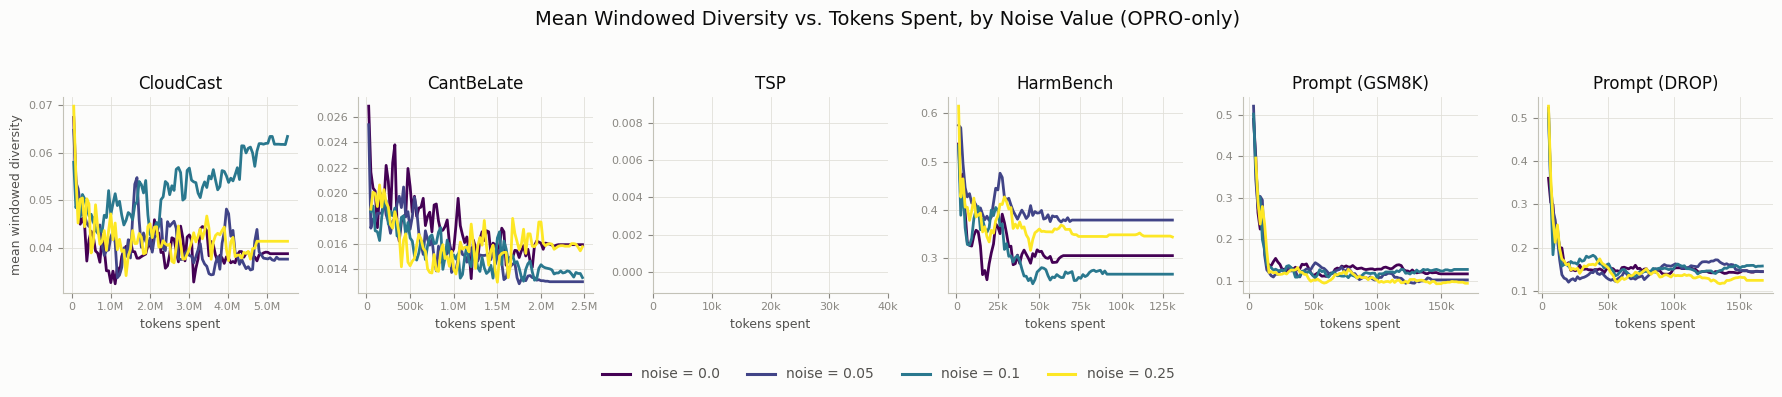

In [11]:
"""Build the 1x6 figure: mean windowed diversity vs. tokens spent,
OPRO-only, one mean line per noise value (colored by noise, same
NOISE_VALUES/color_for_noise as the by-noise score figure above), no
per-variant lines."""

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    per_noise = diversity_by_column_noise.get(column_key, {})
    if not per_noise:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    # One shared grid per column, across every noise group's own variants,
    # extended to the furthest-along point overall -- same reasoning as
    # every other panel in this notebook.
    grid_end = max(
        tokens.max()
        for variants in per_noise.values()
        for tokens, _ in variants.values()
    )
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    for noise_value in NOISE_VALUES:
        variants = per_noise.get(noise_value)
        if not variants:
            continue
        interpolated = [
            step_interpolate(tokens, diversity, grid)
            for tokens, diversity in variants.values()
        ]
        mean_series = np.nanmean(np.vstack(interpolated), axis=0)
        ax.plot(
            grid, mean_series, color=color_for_noise(noise_value),
            linewidth=2.0, zorder=3,
        )

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean windowed diversity', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=color_for_noise(n), lw=2.2, label=f'noise = {n}')
    for n in NOISE_VALUES
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.15),
)

fig.suptitle(
    'Mean Windowed Diversity vs. Tokens Spent, by Noise Value (OPRO-only)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual2_diversity_by_noise.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "clean_visual2_diversity_by_noise.pdf")}')

plt.show()


## Trajectory summary scatter: early score & similarity vs. max score achieved (OPRO-only, all noise values)

A different shape from every visual above: each **point** here is one whole
trajectory (one OPRO run), not a time series. 2x6 grid, columns = the same 6
tasks, all 4 noise values pooled together per column (up to 48
trajectories/task).

- **x-axis** (shared within each column, both rows): max score ever achieved
  in that trajectory (its final running-max) -- crash-sentinel scores (see
  `TASK_FAILED_SCORE`, CantBeLate/CloudCast only) excluded, same as
  everywhere else in this notebook family.
- **Top row y**: mean raw score of that trajectory's first N non-crash
  generated solutions.
- **Bottom row y**: mean pairwise COSINE SIMILARITY (not distance -- higher
  means more similar / less diverse) among those same N solutions'
  embeddings -- same embedding-model pairing as the diversity visuals above
  (Qodo for CantBeLate/CloudCast, all-MiniLM for the rest), reusing the
  already-populated `embedding_cache/clean_visuals/` cache.
- **"First N"** (confirmed with the user): the seed (record 0) is excluded
  since it isn't optimizer-generated, and so are any crash-sentinel records
  encountered along the way -- i.e. the first N *real* generated solutions,
  skipping over crashes rather than counting them, so both rows are computed
  over the exact same N records per trajectory. A trajectory with fewer than
  N non-crash generated solutions yet is skipped. N is 10 for every task
  (`EARLY_WINDOW_DEFAULT`) -- `TASK_EARLY_WINDOW` exists for a per-task
  override (tried 5 for CantBeLate, reverted back to 10 per the user).
- **Color = mutator** (kincontext/DE/GA/GEPA), not task -- a genuine
  within-panel comparison, so also shape-coded (a 4th category can't clear
  the palette's all-pairs CVD floor on color alone). Two versions below:
  one OLS fit pooled across all 4 mutators per panel, one with a separate
  OLS fit per mutator -- both annotate slope (m) and R^2 per box.

In [12]:
"""Per-trajectory summary stats for the 2x6 scatter below.

Reuses runs_by_column_noise (all 4 noise values, TSP-filtered already) and
get_or_build_embeddings (embeddings already cached from the diversity
visuals above for most texts -- only genuinely new ones, if any, get
embedded here).
"""

# Crash-sentinel scores (see llm_optimizer/tasks/{cant_be_late,cloud_cast}.py's
# FAILED_SCORE) -- not a low real score, so excluded from both the max-score
# x-axis and the early window, same stance as general_rollout.ipynb's
# TASK_FAILED_SCORE. harmbench/prompt/tsp have no such sentinel.
TASK_FAILED_SCORE = {'cantbelate': -100_000.0, 'cloudcast': -100_000.0}

# "First N [non-crash] generated solutions" window, seed excluded.
# TASK_EARLY_WINDOW can override the default per task (tried 5 for
# CantBeLate, reverted back to 10 per the user) -- left in place, empty,
# so a future per-task override is a one-line change again.
EARLY_WINDOW_DEFAULT = 10
TASK_EARLY_WINDOW: dict[str, int] = {}


def early_window_for(task_name: str) -> int:
    return TASK_EARLY_WINDOW.get(task_name, EARLY_WINDOW_DEFAULT)


def first_n_generated(records: list[dict], failed_score: float | None, n: int) -> list[dict]:
    """First `n` non-seed, non-crash-sentinel records, in chronological order."""
    generated = records[1:]  # drop the seed (record 0) -- not optimizer-generated
    if failed_score is not None:
        generated = [r for r in generated if r['score'] != failed_score]
    return generated[:n]


def mean_pairwise_cosine_similarity(texts: list[str], embeddings: dict[str, np.ndarray]) -> float:
    """Mean cosine SIMILARITY (not distance) across every pair in `texts`."""
    vecs = np.stack([embeddings[t] for t in texts])
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    unit = vecs / np.where(norms == 0, 1, norms)
    sims = unit @ unit.T
    pair_mask = ~np.eye(len(texts), dtype=bool)
    return float(sims[pair_mask].mean())


trajectory_points: dict[str, list[dict]] = {}

for column_key, by_noise in runs_by_column_noise.items():
    task_name = task_for_column(column_key)
    failed_score = TASK_FAILED_SCORE.get(task_name)
    window = early_window_for(task_name)

    # Resolve each trajectory's first-N-generated window + full-trajectory
    # max score (crash-sentinel excluded from both), and collect the texts
    # that need embeddings along the way.
    trajectories: list[dict] = []
    early_texts: set[str] = set()
    for variants in by_noise.values():
        for label, records in variants.items():
            early = first_n_generated(records, failed_score, window)
            if len(early) < window:
                continue  # not enough real generated solutions yet
            scores = np.array([r['score'] for r in records], dtype=float)
            valid_scores = scores[scores != failed_score] if failed_score is not None else scores
            if len(valid_scores) == 0:
                continue
            trajectories.append({'label': label, 'early': early, 'max_score': valid_scores.max()})
            early_texts.update(r['solution'] for r in early)

    embeddings = get_or_build_embeddings(column_key, early_texts)

    points = []
    for traj in trajectories:
        early_scores = np.array([r['score'] for r in traj['early']], dtype=float)
        early_texts_list = [r['solution'] for r in traj['early']]
        points.append({
            'label': traj['label'],
            'max_score': traj['max_score'],
            'mean_early_score': early_scores.mean(),
            'mean_early_similarity': mean_pairwise_cosine_similarity(early_texts_list, embeddings),
        })
    trajectory_points[column_key] = points

print('trajectory scatter points (window size per task in parens):')
for column_key in COLUMN_ORDER:
    task_name = task_for_column(column_key)
    window = early_window_for(task_name)
    print(f'  {column_key:14s} (first {window}) {len(trajectory_points.get(column_key, [])):2d} trajectories')


[prompt_drop] 479 texts, all cached.
[prompt_gsm8k] 469 texts, all cached.
[cantbelate] 477 texts, all cached.


[cloudcast] 479 texts, all cached.
[tsp] 373 texts, all cached.
[harmbench] 479 texts, all cached.
trajectory scatter points (window size per task in parens):
  cloudcast      (first 10) 48 trajectories
  cantbelate     (first 10) 48 trajectories
  tsp            (first 10) 48 trajectories
  harmbench      (first 10) 48 trajectories
  prompt_gsm8k   (first 10) 48 trajectories
  prompt_drop    (first 10) 48 trajectories


saved to ../figs/clean_visual3_trajectory_summary_scatter.pdf


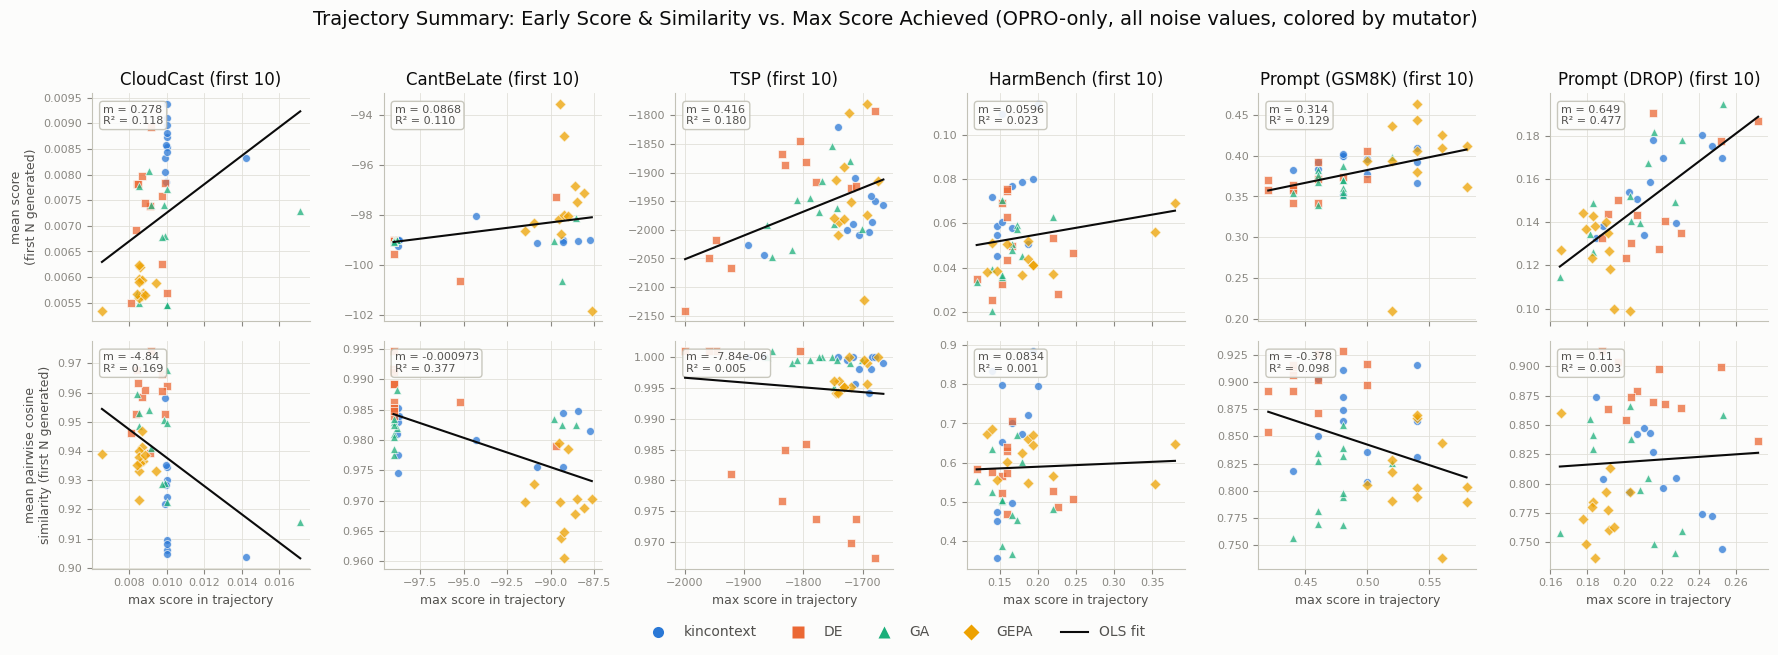

In [13]:
"""Build the 2x6 trajectory-summary scatter figure.

Colored by MUTATOR (not task -- each panel now genuinely mixes 4 colors,
one per mutator, so this is an all-pairs same-panel comparison). Per the
dataviz skill's palette (references/palette.md), only the first 3
categorical slots clear all-pairs CVD separation in both light/dark mode;
a 4th relies on color alone failing the all-pairs floor (yellow vs orange).
Marker SHAPE is added as the secondary channel for the 4th mutator so
identity never depends on hue alone -- the documented mitigation for a
sub-floor slot.

Each panel also gets its own ordinary-least-squares fit line (pooled
across all 4 mutators, not one line per mutator -- a single "does x predict
y here" read per box) with slope (m) and R^2 annotated in a corner box.
"""

MUTATOR_ORDER = ['kincontext', 'DE', 'GA', 'GEPA']
MUTATOR_COLOR = dict(zip(
    MUTATOR_ORDER, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100'], strict=True,
))
MUTATOR_MARKER = dict(zip(MUTATOR_ORDER, ['o', 's', '^', 'D'], strict=True))


def mutator_for_label(label: str) -> str:
    """optimizer_label ('opro_{mutator}_{strategy}') -> mutator.

    Plain split works since every mutator token (kincontext/DE/GA/GEPA) is
    single-word -- no underscore inside it to collide with the split.
    """
    return label.split('_')[1]


def fit_line(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float]:
    """OLS slope/intercept/R^2 for a scatter of (x, y)."""
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
    return slope, intercept, r2


def draw_fit_line(ax: plt.Axes, x: np.ndarray, y: np.ndarray) -> None:
    slope, intercept, r2 = fit_line(x, y)
    x_line = np.array([x.min(), x.max()])
    ax.plot(
        x_line, slope * x_line + intercept, color=INK_PRIMARY,
        linewidth=1.5, linestyle='-', zorder=4,
    )
    ax.text(
        0.05, 0.95, f'm = {slope:.3g}\nR² = {r2:.3f}',
        transform=ax.transAxes, va='top', ha='left', fontsize=8,
        color=INK_SECONDARY,
        bbox={
            'boxstyle': 'round,pad=0.3', 'facecolor': SURFACE,
            'edgecolor': BASELINE, 'alpha': 0.9,
        },
    )


fig, axes = plt.subplots(
    2, 6, figsize=(18, 6), facecolor=SURFACE, sharex='col', sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax_top = axes[0, col_idx]
    ax_bot = axes[1, col_idx]
    ax_top.set_facecolor(SURFACE)
    ax_bot.set_facecolor(SURFACE)
    window = early_window_for(task_for_column(column_key))
    ax_top.set_title(
        f'{COLUMN_TITLES[column_key]} (first {window})', color=INK_PRIMARY, fontsize=12,
    )

    points = trajectory_points.get(column_key, [])
    if not points:
        for ax in (ax_top, ax_bot):
            ax.text(
                0.5, 0.5, 'no data yet', ha='center', va='center',
                color=INK_MUTED, fontsize=10, transform=ax.transAxes,
            )
        continue

    x = np.array([p['max_score'] for p in points])
    y_top = np.array([p['mean_early_score'] for p in points])
    y_bot = np.array([p['mean_early_similarity'] for p in points])
    mutators = [mutator_for_label(p['label']) for p in points]

    for mutator in MUTATOR_ORDER:
        mask = np.array([m == mutator for m in mutators])
        if not mask.any():
            continue
        ax_top.scatter(
            x[mask], y_top[mask], s=32, color=MUTATOR_COLOR[mutator],
            marker=MUTATOR_MARKER[mutator], alpha=0.75,
            linewidths=0.6, edgecolors=SURFACE, zorder=3,
        )
        ax_bot.scatter(
            x[mask], y_bot[mask], s=32, color=MUTATOR_COLOR[mutator],
            marker=MUTATOR_MARKER[mutator], alpha=0.75,
            linewidths=0.6, edgecolors=SURFACE, zorder=3,
        )

    draw_fit_line(ax_top, x, y_top)
    draw_fit_line(ax_bot, x, y_bot)

    ax_bot.set_xlabel('max score in trajectory', color=INK_SECONDARY, fontsize=9)
    for ax in (ax_top, ax_bot):
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        for spine in ax.spines.values():
            spine.set_color(BASELINE)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(color=GRIDLINE, linewidth=0.6)
        ax.set_axisbelow(True)

axes[0, 0].set_ylabel(
    'mean score\n(first N generated)', color=INK_SECONDARY, fontsize=9,
)
axes[1, 0].set_ylabel(
    'mean pairwise cosine\nsimilarity (first N generated)',
    color=INK_SECONDARY, fontsize=9,
)

legend_handles = [
    plt.Line2D(
        [0], [0], marker=MUTATOR_MARKER[m], color='none',
        markerfacecolor=MUTATOR_COLOR[m], markeredgecolor='none',
        markersize=8, label=m,
    )
    for m in MUTATOR_ORDER
] + [
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=1.5, label='OLS fit'),
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=5,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.05),
)

fig.suptitle(
    'Trajectory Summary: Early Score & Similarity vs. Max Score Achieved '
    '(OPRO-only, all noise values, colored by mutator)',
    color=INK_PRIMARY, fontsize=14, y=1.02,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual3_trajectory_summary_scatter.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual3_trajectory_summary_scatter.pdf")}',
)

plt.show()


## Trajectory summary scatter, per-mutator OLS fits (OPRO-only, all noise values)

Same 2x6 grid, same points, same axes as the pooled-fit version above --
but instead of one OLS line fit across all 4 mutators pooled together, each
mutator gets its OWN fit line (and its own slope/R^2), drawn in that
mutator's own color. This asks a different question per panel: not "does x
predict y overall" but "does x predict y *within* each mutator", which can
diverge from the pooled answer (e.g. a mutator-level trend hidden inside a
flat pooled fit, or vice versa -- Simpson's-paradox-shaped effects only
show up in the per-mutator lines). The four (m, R^2) pairs are listed
together in one color-coded corner box per panel rather than four separate
boxes, to keep 12 panels x 4 mutators legible.

saved to ../figs/clean_visual3_trajectory_summary_scatter_per_mutator_fit.pdf


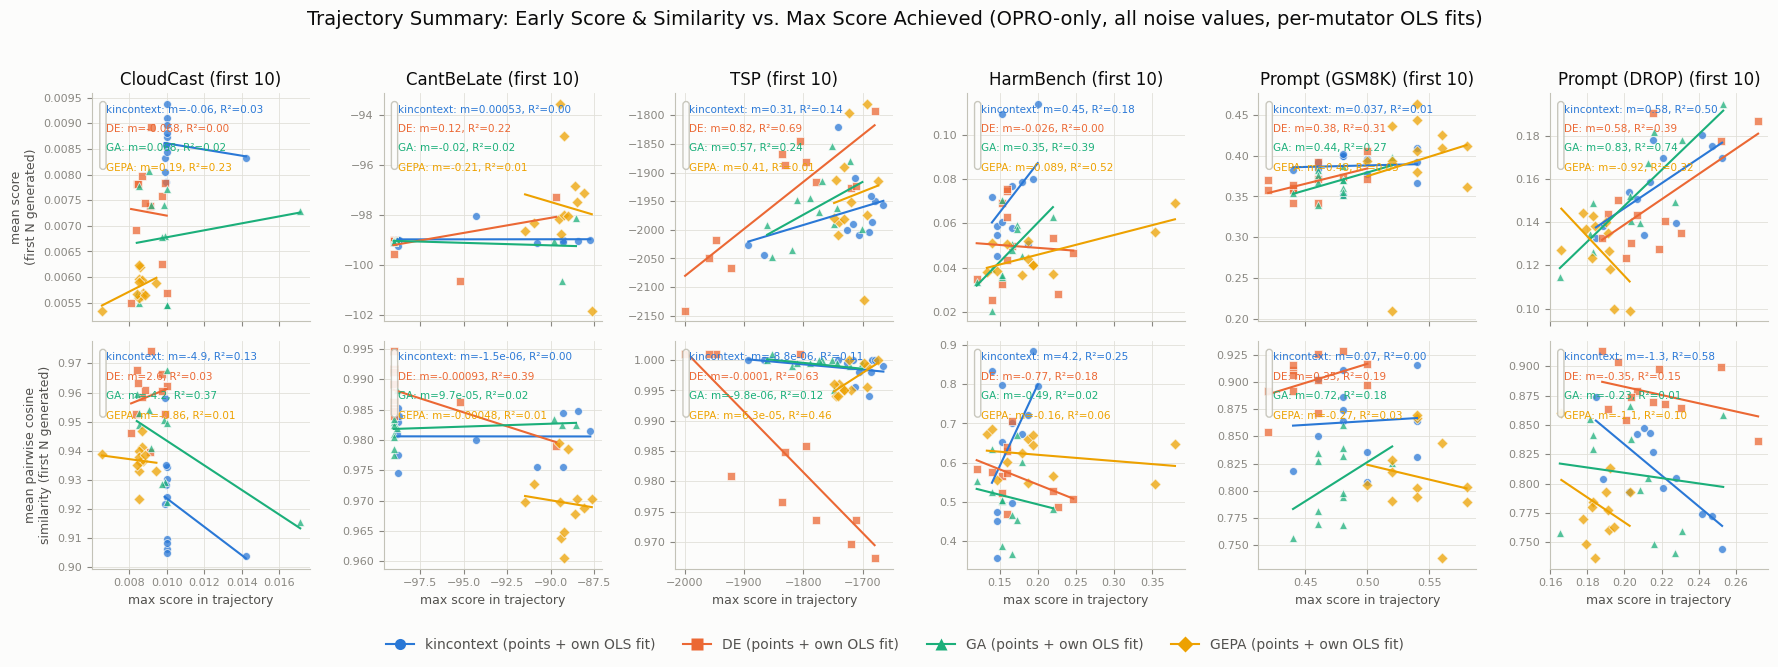

In [14]:
"""Build the 2x6 trajectory-summary scatter figure, per-mutator OLS fits.

Reuses trajectory_points / MUTATOR_ORDER / MUTATOR_COLOR / MUTATOR_MARKER /
mutator_for_label / fit_line from the pooled-fit cell above -- only the fit
line and annotation are per-mutator instead of pooled.
"""

fig, axes = plt.subplots(
    2, 6, figsize=(18, 6), facecolor=SURFACE, sharex='col', sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax_top = axes[0, col_idx]
    ax_bot = axes[1, col_idx]
    ax_top.set_facecolor(SURFACE)
    ax_bot.set_facecolor(SURFACE)
    window = early_window_for(task_for_column(column_key))
    ax_top.set_title(
        f'{COLUMN_TITLES[column_key]} (first {window})', color=INK_PRIMARY, fontsize=12,
    )

    points = trajectory_points.get(column_key, [])
    if not points:
        for ax in (ax_top, ax_bot):
            ax.text(
                0.5, 0.5, 'no data yet', ha='center', va='center',
                color=INK_MUTED, fontsize=10, transform=ax.transAxes,
            )
        continue

    x = np.array([p['max_score'] for p in points])
    y_top = np.array([p['mean_early_score'] for p in points])
    y_bot = np.array([p['mean_early_similarity'] for p in points])
    mutators = np.array([mutator_for_label(p['label']) for p in points])

    fit_lines_top = []
    fit_lines_bot = []
    for mutator in MUTATOR_ORDER:
        mask = mutators == mutator
        color = MUTATOR_COLOR[mutator]

        ax_top.scatter(
            x[mask], y_top[mask], s=32, color=color,
            marker=MUTATOR_MARKER[mutator], alpha=0.75,
            linewidths=0.6, edgecolors=SURFACE, zorder=3,
        )
        ax_bot.scatter(
            x[mask], y_bot[mask], s=32, color=color,
            marker=MUTATOR_MARKER[mutator], alpha=0.75,
            linewidths=0.6, edgecolors=SURFACE, zorder=3,
        )

        # Need >= 2 points (and non-degenerate x) for a fit to mean anything.
        if mask.sum() >= 2 and np.ptp(x[mask]) > 0:
            slope, intercept, r2 = fit_line(x[mask], y_top[mask])
            x_line = np.array([x[mask].min(), x[mask].max()])
            ax_top.plot(
                x_line, slope * x_line + intercept, color=color,
                linewidth=1.5, zorder=4,
            )
            fit_lines_top.append((mutator, slope, r2))

            slope_b, intercept_b, r2_b = fit_line(x[mask], y_bot[mask])
            x_line_b = np.array([x[mask].min(), x[mask].max()])
            ax_bot.plot(
                x_line_b, slope_b * x_line_b + intercept_b, color=color,
                linewidth=1.5, zorder=4,
            )
            fit_lines_bot.append((mutator, slope_b, r2_b))

    for ax, fits in ((ax_top, fit_lines_top), (ax_bot, fit_lines_bot)):
        if not fits:
            continue
        # One shared background box behind the stacked per-mutator lines
        # (matplotlib text is single-color, so each mutator's (m, R^2)
        # line is its own colored text artist; this invisible-text call
        # just reserves/draws the bordered box behind them, sized to fit).
        ax.text(
            0.05, 0.95, '\n'.join('' for _ in fits), transform=ax.transAxes,
            va='top', ha='left', fontsize=7.5, linespacing=1.9,
            bbox={
                'boxstyle': 'round,pad=0.3', 'facecolor': SURFACE,
                'edgecolor': BASELINE, 'alpha': 0.9,
            },
            zorder=5,
        )
        y_cursor = 0.95
        for mutator, slope, r2 in fits:
            ax.text(
                0.065, y_cursor, f'{mutator}: m={slope:.2g}, R²={r2:.2f}',
                transform=ax.transAxes, va='top', ha='left', fontsize=7.5,
                color=MUTATOR_COLOR[mutator], zorder=6,
            )
            y_cursor -= 0.085

    ax_bot.set_xlabel('max score in trajectory', color=INK_SECONDARY, fontsize=9)
    for ax in (ax_top, ax_bot):
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        for spine in ax.spines.values():
            spine.set_color(BASELINE)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(color=GRIDLINE, linewidth=0.6)
        ax.set_axisbelow(True)

axes[0, 0].set_ylabel(
    'mean score\n(first N generated)', color=INK_SECONDARY, fontsize=9,
)
axes[1, 0].set_ylabel(
    'mean pairwise cosine\nsimilarity (first N generated)',
    color=INK_SECONDARY, fontsize=9,
)

legend_handles = [
    plt.Line2D(
        [0], [0], marker=MUTATOR_MARKER[m], color=MUTATOR_COLOR[m],
        markerfacecolor=MUTATOR_COLOR[m], markeredgecolor='none',
        markersize=8, lw=1.5, label=f'{m} (points + own OLS fit)',
    )
    for m in MUTATOR_ORDER
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.07),
)

fig.suptitle(
    'Trajectory Summary: Early Score & Similarity vs. Max Score Achieved '
    '(OPRO-only, all noise values, per-mutator OLS fits)',
    color=INK_PRIMARY, fontsize=14, y=1.02,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual3_trajectory_summary_scatter_per_mutator_fit.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual3_trajectory_summary_scatter_per_mutator_fit.pdf")}',
)

plt.show()


## Similarity-threshold calibration (per-task `sim_thresh` cutoffs)

Not a plot -- an analysis to help pick `--sim_thresh` values for
`llm_optimizer/optimizers/opro.py`'s diversity check (`SolutionBank.eval_cosine_sim`,
gated by `main.py`'s `--sim_thresh`).

**How `sim_thresh` actually works** (confirmed by reading `main.py` +
`opro.py`): when a new candidate is added, its embedding is compared
against every solution currently in the active pool via raw cosine
**similarity** (not distance), and the candidate is rejected only if its
similarity to the single closest pool member exceeds `sim_thresh`. So
**higher `sim_thresh` is MORE admissive** (harder to exceed -> fewer
rejections -> a more lenient/permissive diversity gate); **lower is
stricter** (rejects more candidates as "too similar").

**This analysis**: `llm_optimizer/utils.py`'s `get_similarity_percentiles`
(its last function) -- embeds a list of texts, computes every pairwise
cosine similarity, and returns the requested percentiles of that
distribution. Run per task, pooling **every solution from all 12 noise=0
OPRO variants** (`runs_by_column` -- already loaded above, TSP already
filtered to valid traces via `filter_tsp_records`), using each task's own
embedding model (Qodo for CantBeLate/CloudCast, all-MiniLM for the rest --
same pairing as the diversity visuals).

**Caveat**: this is the percentile of the *overall pairwise* similarity
distribution (every pair, pooled), not the *max-similarity-to-nearest-pool-
neighbor* distribution `eval_cosine_sim` actually thresholds at generation
time -- a max-of-many-comparisons statistic skews higher than a random pair
drawn from the same pool, so treat these percentiles as a calibration
starting point / ballpark, not an exact "X% of candidates get rejected at
this threshold" guarantee.

In [15]:
"""Similarity-threshold calibration: get_similarity_percentiles per task,
pooling all solutions from the 12 noise=0 OPRO variants (runs_by_column).
"""

from llm_optimizer.utils import get_similarity_percentiles

SIM_PERCENTILES = (25.0, 50.0, 75.0, 90.0, 95.0, 99.0)

sim_threshold_report: dict[str, dict[str, float]] = {}

for column_key in COLUMN_ORDER:
    variants = runs_by_column.get(column_key, {})
    if not variants:
        print(f'[{column_key}] no data yet, skipping')
        continue

    texts = [r['solution'] for records in variants.values() for r in records]
    model_name = embed_model_for(column_key)

    result = get_similarity_percentiles(
        texts, model_name=model_name, percentiles=SIM_PERCENTILES, device=EMBED_DEVICE,
    )
    sim_threshold_report[column_key] = result

    print(f'{COLUMN_TITLES[column_key]:16s} ({len(texts)} solutions pooled, {model_name}):')
    for p in SIM_PERCENTILES:
        print(f'    {p:5.1f}th percentile: {result[f"{p}th_percentile"]:.4f}')
    print()


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

CloudCast        (2096 solutions pooled, Qodo/Qodo-Embed-1-1.5B):
     25.0th percentile: 0.8699
     50.0th percentile: 0.8924
     75.0th percentile: 0.9197
     90.0th percentile: 0.9388
     95.0th percentile: 0.9553
     99.0th percentile: 0.9995



Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

CantBeLate       (2412 solutions pooled, Qodo/Qodo-Embed-1-1.5B):
     25.0th percentile: 0.9470
     50.0th percentile: 0.9580
     75.0th percentile: 0.9678
     90.0th percentile: 0.9769
     95.0th percentile: 0.9823
     99.0th percentile: 0.9921



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

HarmBench        (612 solutions pooled, all-MiniLM-L6-v2):
     25.0th percentile: 0.2763
     50.0th percentile: 0.3655
     75.0th percentile: 0.4702
     90.0th percentile: 0.5986
     95.0th percentile: 0.6903
     99.0th percentile: 0.8596



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Prompt (GSM8K)   (612 solutions pooled, all-MiniLM-L6-v2):
     25.0th percentile: 0.6253
     50.0th percentile: 0.7069
     75.0th percentile: 0.7832
     90.0th percentile: 0.8485
     95.0th percentile: 0.8899
     99.0th percentile: 0.9531



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Prompt (DROP)    (612 solutions pooled, all-MiniLM-L6-v2):
     25.0th percentile: 0.6778
     50.0th percentile: 0.7409
     75.0th percentile: 0.7983
     90.0th percentile: 0.8474
     95.0th percentile: 0.8746
     99.0th percentile: 0.9350



## Curated initial populations by iteration budget (diversity-rejection / greedy / greedy-no-dedup, OPRO-only)

Uses `llm_optimizer.population_curation_utils.curate_population` (not a notebook-local
reimplementation) to build initial seed populations per-task via `TASK_ITERATION_BUDGETS`:
CloudCast/CantBeLate `2,3,5,10,20`; HarmBench `2,3,4,5,7`; TSP `2,3,5,7,9`; Prompt GSM8K/
DROP `2,3,4,5,7` (all have plenty of runway on disk) -- keys `<= budget` from each pooled
bank; every bank's keys start at `1`, so budget `N` pools exactly `N` entries per bank,
`12 * N` raw candidates total across the 12 pooled runs -- via four curation labels
(`tournament` dropped -- no longer part of this comparison):

- **`diversity` (p=0.98)**: score-first greedy acceptance, rejecting a candidate only if its
  max similarity to an already-accepted member exceeds the pool's own 98th-percentile
  pairwise similarity -- a light-touch filter (rejects roughly the most-similar 2% of
  pairs), now that `population_curation_utils.py`'s percentile-scale bug is fixed.
- **`greedy`**: top-N by score, no diversity filtering, no embedding call at all -- a real
  third branch in `curate_population` (`_greedy_sample`). Originally tried as
  `curation_type='diversity', p=1.0` (100th-percentile threshold makes the diversity accept
  check a no-op), but that hit a floating-point edge case on TSP where a near-duplicate pair
  sitting at the pool's exact max similarity could get wrongly rejected and never backfilled
  -- the direct top-N sort has no such edge case.
- **`greedy_no_dedup`**: same top-N-by-score sort as `greedy`, but `dedup='none'` -- every
  occurrence of a repeated solution counts as its own candidate, so a duplicated high
  scorer can crowd out real diversity. A deliberate worst-case baseline (folded into this
  same grid, row for row against the deduped types, rather than kept as a separate
  section), not a recommended policy.
- **`greedy_n1`**: `greedy` (deduped) with the new `population_size=1` override -- just the
  single best candidate at each budget, no population at all. The degenerate "ignore
  diversity/pop-size entirely" baseline at the other extreme from `greedy_no_dedup`.

`diversity` uses each task's own embedding model (`embed_model_for` -- Qodo-Embed-1.5B for
CloudCast/CantBeLate, all-MiniLM-L6-v2 for the rest), same pairing as the diversity visuals
above, rather than `curate_population`'s flat all-MiniLM default. `greedy`/`greedy_no_dedup`
need no embedding model at all.

**Pool**: the same 12 canonical noise=0 OPRO variant banks used throughout this notebook
(`raw_banks_by_column` below) -- loaded straight from disk as raw `{iter_key: entry}`
dicts, since `curate_population`'s pooling helper walks a bank's own keys directly and
expects that shape, unlike `load_bank`'s flattened, index-ordered list used elsewhere in
this notebook. TSP gets the same invalid-trace filter (`is_valid_tsp_trace`) applied to its
raw bank before pooling, same as everywhere else TSP is touched here.

**Dedup**: `_pool_candidates_within_budget` keeps the HIGHEST observed score when the same
solution text appears more than once in the pooled banks (`dedup='max'`, used by `diversity`
and `greedy` here) -- previously kept whichever occurrence it encountered first. Confirmed
necessary on real data: HarmBench's target generation isn't temperature-pinned (see
`harm_bench.py`/`prompt_lm`), so the exact same trigger text gets independently re-sampled
and re-judged each time it's evaluated -- e.g. one trigger scored anywhere from 0.093 to
0.187 across its 12 separate evaluations at iteration 1 alone. `greedy_no_dedup` uses
`dedup='none'` instead (see above) -- deliberately not fixed, as the worst-case baseline.

4 curation labels x 5 budgets across the 6 tasks (5 budgets each, every task) = 120 curated
populations, each saved to
`../currated_initial_pops_w_diversity_rejection/<task>/<curation_type>_budget_<N>.json` and
reported (token cost, population size actually achieved, n_unique_texts, mean score, max
score) in `curation_df` at the bottom.

In [16]:
"""Raw (unflattened) noise=0 bank dicts per (column, OPRO variant), for the
population-curation section below. Same discovery criteria as the noise=0
score/diversity cells above (opro_*, noise=00, inference-model pin) --
reuses EXPERIMENT_DIR/noise_token/parse_run_dir/inference_model_ok/
find_bank_path/is_valid_tsp_trace from the loader cell -- but keeps each
bank as its raw {iter_key: entry} dict (population_curation_utils.
curate_population pools directly over that raw shape) rather than
load_bank's flattened, index-ordered list.
"""

import json

raw_banks_by_column: dict[str, dict[str, dict]] = {}

for dirname in sorted(os.listdir(EXPERIMENT_DIR)):
    run_dir = os.path.join(EXPERIMENT_DIR, dirname)
    if not os.path.isdir(run_dir) or not dirname.startswith('opro_'):
        continue
    if noise_token(dirname) != '00':
        continue
    task_name, column_key, mutator, sampling_strategy = parse_run_dir(dirname)
    if not inference_model_ok(dirname, task_name):
        continue

    optimizer_label = f'opro_{mutator}_{sampling_strategy}'
    bank_path = find_bank_path(run_dir)
    if bank_path is None:
        continue

    with open(bank_path, encoding='utf-8') as f:
        raw_bank = json.load(f)

    if task_name == 'tsp':
        filtered_bank = {
            k: v for k, v in raw_bank.items() if is_valid_tsp_trace(v['solution'])
        }
        n_dropped = len(raw_bank) - len(filtered_bank)
        if n_dropped:
            print(f'[tsp] dropped {n_dropped} invalid-trace record(s) from {dirname}')
        raw_bank = filtered_bank

    if raw_bank:
        raw_banks_by_column.setdefault(column_key, {})[optimizer_label] = raw_bank

print(f'{len(raw_banks_by_column)} columns loaded for curation:')
for column_key, variants in sorted(raw_banks_by_column.items()):
    sizes = sorted(len(b) for b in variants.values())
    print(
        f'  {column_key:14s} {len(variants):2d}/12 variants  '
        f'raw entry counts {sizes[0]}-{sizes[-1]}',
    )


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 6 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 7 invalid-trace record(s) from opro_gemini-37-flash_GA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_GA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 8 invalid-trace record(s) from opro_gemini-37-flash_GEPA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


6 columns loaded for curation:
  cantbelate     12/12 variants  raw entry counts 201-201
  cloudcast      12/12 variants  raw entry counts 76-201
  harmbench      12/12 variants  raw entry counts 51-51
  prompt_drop    12/12 variants  raw entry counts 51-51
  prompt_gsm8k   12/12 variants  raw entry counts 51-51
  tsp            12/12 variants  raw entry counts 143-201


In [17]:
"""Curate initial populations via population_curation_utils.curate_population,
one per (task, curation label, iteration_budget) -- pooling the 12 noise=0
raw bank dicts loaded above. Three curation labels:

- diversity (p=0.98): now that population_curation_utils.py's percentile
  bug is fixed, a genuine 98th-percentile similarity threshold --
  permissive, rejects only the most-similar ~2% of pairs.
- greedy: top-N by score, no diversity filtering, no embedding call at
  all. A real third branch in curate_population (_greedy_sample) --
  originally tried as curation_type='diversity', p=1.0 (100th-percentile
  threshold makes the diversity accept check a no-op), but that hit a
  floating-point edge case on TSP where a near-duplicate pair sitting at
  the pool's exact max similarity could get wrongly rejected and never
  backfilled, so the population fell short of the true top-N. The direct
  top-N sort has no such edge case (verified: exact match against a plain
  top-K sort, including the TSP case that broke the p=1.0 trick).
- greedy_no_dedup: same top-N-by-score sort, but dedup='none' -- every
  occurrence of a repeated solution counts as its own candidate, so a
  duplicated high scorer can crowd out real diversity. A deliberate
  worst-case baseline (see population_curation_utils.py's dedup='none'
  docstring), not a recommended policy -- included here (rather than as
  a separate section) so it's directly comparable, row for row, against
  the deduped curation types above.
- greedy_n1: greedy (deduped, top-N-by-score) with the new
  population_size=1 override -- just the single best candidate at each
  budget, no population at all. The degenerate "ignore diversity/pop-size
  entirely, take the best you've seen" baseline at the other extreme
  from greedy_no_dedup.

(tournament dropped -- no longer part of this comparison.)

Diversity's embedding model follows the same embed_model_for() task
pairing used everywhere else in this notebook rather than
curate_population's flat all-MiniLM default. greedy/greedy_no_dedup need
no embedding model at all.

Each curated population is reported (token cost, mean/max score, and
n_unique_texts -- how many of the population's slots are actually
distinct solutions vs. wasted on exact repeats -- assembled into
curation_df in the next cell) and saved to disk under
POPULATION_DIR/<column>/<label>_budget_<N>.json so it's usable as an
actual OPRO seed population later.
"""

import json

from llm_optimizer.population_curation_utils import curate_population

DEFAULT_ITERATION_BUDGETS = [2, 3, 4, 5]
# CloudCast, CantBeLate, and HarmBench have plenty of runway on disk
# (raw bank sizes 76-201, 201, and 51 entries respectively, per the
# coverage report above) to support larger budgets too -- CloudCast/
# CantBeLate extended with 10, 20 and dropped 4; HarmBench swapped 10
# for 7. TSP swapped 4 for 7 and dropped 10 (raw bank sizes 143-201).
# Prompt GSM8K/DROP extended with 7 (raw bank sizes 51, plenty of
# runway). Every other task keeps the default 4.
TASK_ITERATION_BUDGETS = {
    'cloudcast': [2, 3, 5, 10, 20],
    'cantbelate': [2, 3, 5, 10, 20],
    'harmbench': [2, 3, 4, 5, 7],
    'tsp': [2, 3, 5, 7, 9],
    'prompt_gsm8k': [2, 3, 4, 5, 7],
    'prompt_drop': [2, 3, 4, 5, 7],
}


def iteration_budgets_for(column_key):
    return TASK_ITERATION_BUDGETS.get(column_key, DEFAULT_ITERATION_BUDGETS)


# (report label, curate_population's curation_type, p, dedup,
# population_size) -- p is unused for the greedy variants but
# curate_population still accepts the kwarg, so pass nan there for a
# self-documenting report column rather than a misleading leftover
# number. population_size=None keeps curate_population's adaptive
# min(max_population_size, total_candidates) sizing; greedy_n1 overrides
# it to an exact 1.
CURATION_CONFIGS = [
    ('diversity', 'diversity', 0.98, 'max', None),
    ('greedy', 'greedy', float('nan'), 'max', None),
    ('greedy_no_dedup', 'greedy', float('nan'), 'none', None),
    ('greedy_n1', 'greedy', float('nan'), 'max', 1),
]
POPULATION_DIR = '../currated_initial_pops_w_diversity_rejection'

curation_rows = []

for column_key in COLUMN_ORDER:
    variants = raw_banks_by_column.get(column_key, {})
    if not variants:
        print(f'[{column_key}] no raw banks loaded, skipping')
        continue

    solution_banks = list(variants.values())
    embed_model_name = embed_model_for(column_key)
    task_dir = os.path.join(POPULATION_DIR, column_key)
    os.makedirs(task_dir, exist_ok=True)

    for label, curation_type, p, dedup, population_size in CURATION_CONFIGS:
        for budget in iteration_budgets_for(column_key):
            population = curate_population(
                solution_banks,
                iteration_budget=budget,
                curation_type=curation_type,
                p=p,
                embed_model_name=embed_model_name,
                dedup=dedup,
                population_size=population_size,
            )
            if not population:
                print(
                    f'[{column_key}] {label} (p={p}) budget={budget}: '
                    'empty population, skipping',
                )
                continue

            scores = np.array([item['score'] for item in population], dtype=float)
            token_cost = population[-1].get('cumulative_tokens_spent', 0)
            n_unique_texts = len({item['solution'] for item in population})

            out_path = os.path.join(task_dir, f'{label}_budget_{budget}.json')
            save_payload = {
                str(idx): {
                    'solution': item['solution'],
                    'score': item['score'],
                    **(
                        {'cumulative_tokens_spent': item['cumulative_tokens_spent']}
                        if 'cumulative_tokens_spent' in item
                        else {}
                    ),
                }
                for idx, item in enumerate(population)
            }
            with open(out_path, 'w', encoding='utf-8') as f:
                json.dump(save_payload, f, indent=2, ensure_ascii=False)

            curation_rows.append({
                'task': COLUMN_TITLES[column_key],
                'curation_type': label,
                'p': p,
                'iteration_budget': budget,
                'population_size': len(population),
                'n_unique_texts': n_unique_texts,
                'token_cost': token_cost,
                'mean_score': scores.mean(),
                'max_score': scores.max(),
            })

print(f'saved curated populations to {POPULATION_DIR}/')


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

saved curated populations to ../currated_initial_pops_w_diversity_rejection/


In [18]:
"""Curated-population report: token cost + mean/max score, one row per
(task, curation_type, iteration_budget). Row order follows COLUMN_ORDER x
CURATION_CONFIGS x ITERATION_BUDGETS (curation_rows' insertion order) --
not re-sorted, so it reads top-to-bottom the same way the rest of this
notebook orders tasks.
"""

import pandas as pd

curation_df = pd.DataFrame(curation_rows)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
curation_df


,task,curation_type,p,iteration_budget,population_size,n_unique_texts,token_cost,mean_score,max_score
0,CloudCast,diversity,0.98,2,13,13,66547,0.01,0.01
1,CloudCast,diversity,0.98,3,15,15,170225,0.01,0.01
2,CloudCast,diversity,0.98,5,15,15,442671,0.01,0.01
3,CloudCast,diversity,0.98,10,15,15,1265095,0.01,0.01
4,CloudCast,diversity,0.98,20,15,15,3119564,0.01,0.01
...,...,...,...,...,...,...,...,...,...
115,Prompt (DROP),greedy_n1,NaN,2,1,1,12773,0.19,0.19
116,Prompt (DROP),greedy_n1,NaN,3,1,1,29840,0.19,0.19
117,Prompt (DROP),greedy_n1,NaN,4,1,1,55236,0.19,0.19
118,Prompt (DROP),greedy_n1,NaN,5,1,1,81312,0.19,0.19


## Curated populations overlaid on mean running-max score (token cost vs. max score)

One scatter dot per curated population from the section above -- x = token cost (sum
across the 12 pooled noise=0 runs at that iteration budget), y = max score achieved in
that population (TSP in the same distance/log space as its line panel) -- colored by
curation type (tournament / diversity / greedy; the only 3 palette slots that clear the
all-pairs CVD floor for a scatter chart per the dataviz skill's `references/palette.md`).
Two companion figures, reusing the exact background from the two score figures above:

- `clean_visual1_row2_opro_only_with_curated_pops.pdf` -- noise=0 backdrop.
- `clean_visual1_row2_opro_by_noise_with_curated_pops.pdf` -- by-noise backdrop (the
  populations themselves are still pooled from noise=0 data only -- see the curation
  section above -- shown against this backdrop too for scale reference against the full
  noise-value comparison).

**Caveat**: a population dot's x-position is the SUM of tokens spent across all 12
pooled source runs at that budget, not one run's own cumulative spend the way this axis
is used everywhere else in this notebook -- read these dots as "total cost to build this
seed population", not a literal point on any single trajectory.

**TSP's x-axis is widened just for these two figures** (`TSP_POP_XLIM`, computed from the
actual population token costs) -- its line panel is normally zoomed to `(0, 40k)` tokens
for legibility, but every TSP population costs 95k-412k tokens and would be invisible at
that zoom.

saved to ../figs/clean_visual1_row2_opro_only_with_curated_pops.pdf


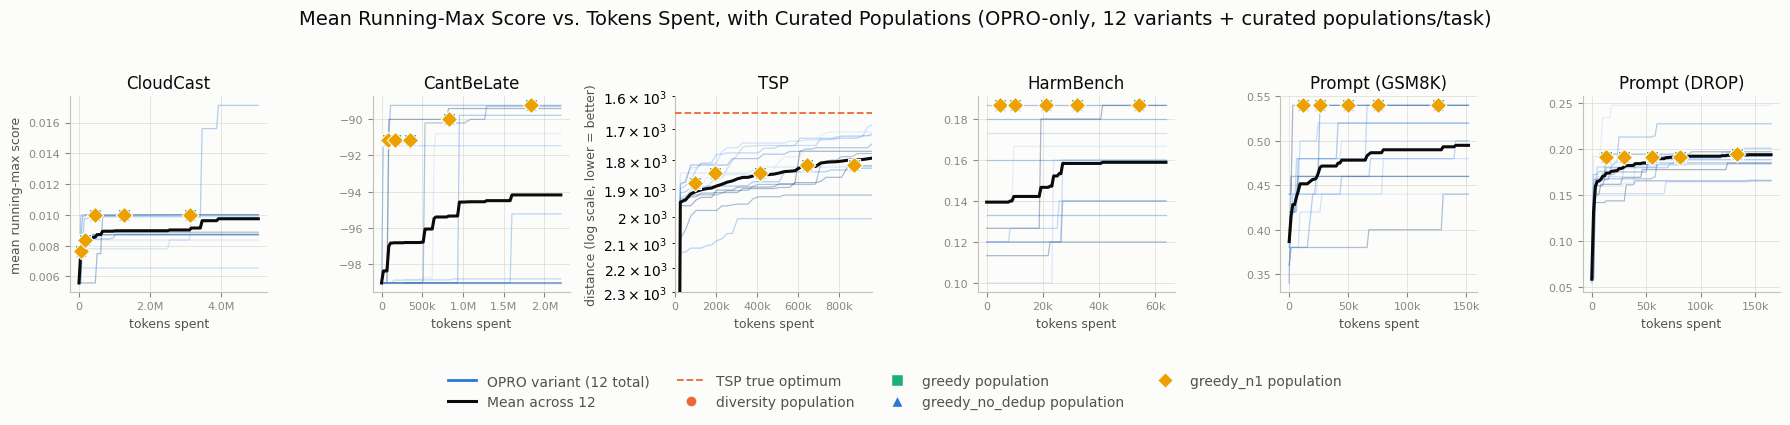

In [19]:
"""Companion to the noise=0 score figure above (clean_visual1_row2_opro_only),
with one scatter dot per curated population (token cost, max score in the
population) overlaid, colored by curation_type. Saved as a SEPARATE file
so the original clean line-only figure is untouched.

Population token_cost is the sum across the 12 pooled source runs at that
budget (see the curation cell above) -- a different quantity than this
axis's usual "one run's own cumulative tokens spent", so read these dots
as "total cost to build this seed population", not literally comparable
run-for-run to where a single trajectory is at that x position.

TSP's line panel is normally zoomed to (0, 40k) tokens for legibility (see
the noise=0 score figure above), but every TSP population costs 95k-412k
tokens -- widened just for this companion figure (TSP_POP_XLIM below) so
the population dots are actually visible; the original clean figure keeps
its tight zoom.
"""

# 4 curation labels now (diversity/greedy/greedy_no_dedup/greedy_n1) --
# only the first 3 palette slots (blue/orange/aqua) clear the all-pairs
# CVD floor for a scatter-type chart, per references/palette.md; slot 4
# (yellow) pairs with orange and fails that floor on color alone, so
# CURATION_MARKER below carries a secondary (shape) channel for every
# label -- same documented mitigation as MUTATOR_MARKER in the
# trajectory-scatter section above.
CURATION_COLOR = {
    'diversity': '#eb6834',  # slot 2 (orange)
    'greedy': '#1baf7a',  # slot 3 (aqua)
    'greedy_no_dedup': '#2a78d6',  # slot 1 (blue)
    'greedy_n1': '#eda100',  # slot 4 (yellow) -- needs the marker-shape
    # channel below, not color-safe alone against orange.
}
CURATION_MARKER = {
    'diversity': 'o',
    'greedy': 's',
    'greedy_no_dedup': '^',
    'greedy_n1': 'D',
}

TSP_POP_XLIM = (
    0,
    float(curation_df.loc[curation_df['task'] == 'TSP', 'token_cost'].max()) * 1.1,
)


def scatter_curated_populations(ax, column_key, sign, df=None):
    """`df` defaults to the max-dedup curation_df; the min-dedup
    comparison section below passes curation_df_min_dedup instead so
    this same helper draws both variants' companion figures."""
    if df is None:
        df = curation_df
    rows = df[df['task'] == COLUMN_TITLES[column_key]]
    for curation_type, color in CURATION_COLOR.items():
        sub = rows[rows['curation_type'] == curation_type]
        if sub.empty:
            continue
        ax.scatter(
            sub['token_cost'], sign * sub['max_score'],
            color=color, marker=CURATION_MARKER[curation_type], s=70,
            zorder=6, edgecolors=SURFACE, linewidths=0.8,
        )


fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)

    variants = runs_by_column.get(column_key, {})
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)
    if not variants:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    trajectories = {
        label: (
            np.array([r['cumulative_tokens_spent'] for r in records], dtype=float),
            running_max(np.array([r['score'] for r in records], dtype=float)),
        )
        for label, records in variants.items()
    }

    grid_end = max(tokens.max() for tokens, _ in trajectories.values())
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    sign = -1.0 if column_key == 'tsp' else 1.0

    interpolated = []
    for label, (tokens, cummax) in trajectories.items():
        resampled = step_interpolate(tokens, cummax, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, sign * resampled, color=color_for(label), linewidth=0.9,
            alpha=0.35, zorder=2,
        )

    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, sign * mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    scatter_curated_populations(ax, column_key, sign)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key == 'tsp':
        ax.set_xlim(*TSP_POP_XLIM)  # widened for this companion figure only
    elif column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO variant (12 total)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across 12'),
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], marker=CURATION_MARKER[curation_type], color='none',
        markerfacecolor=color, markeredgecolor=SURFACE, markersize=8,
        label=f'{curation_type} population',
    )
    for curation_type, color in CURATION_COLOR.items()
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.24),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, with Curated Populations '
    '(OPRO-only, 12 variants + curated populations/task)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_only_with_curated_pops.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual1_row2_opro_only_with_curated_pops.pdf")}',
)

plt.show()


saved to ../figs/clean_visual1_row2_opro_by_noise_with_curated_pops.pdf


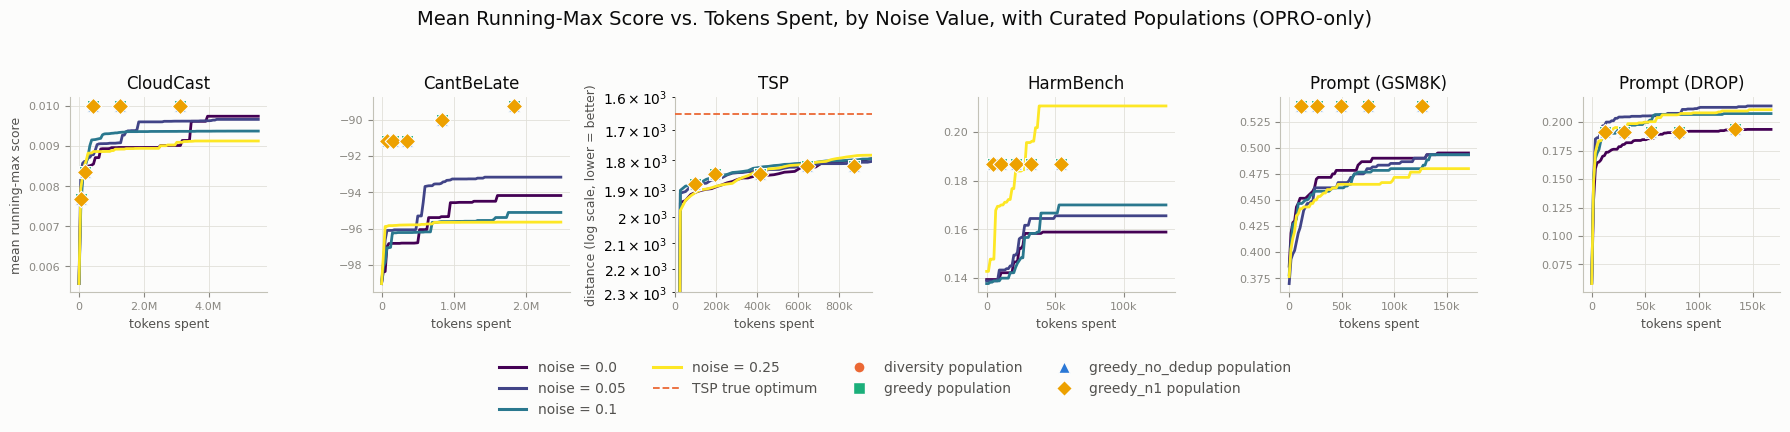

In [20]:
"""Companion to the by-noise score figure above (clean_visual1_row2_opro_by_noise),
with the same curated-population scatter overlay as the companion figure
above. Reuses CURATION_COLOR / TSP_POP_XLIM / scatter_curated_populations
from that cell. Curated populations are pooled from noise=0 data only (see
the curation section above) regardless of which figure they're drawn on --
shown here too so their token cost / max score can be read against the
full noise-value comparison, not just the noise=0-only backdrop.
"""

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    by_noise = runs_by_column_noise.get(column_key, {})
    if not by_noise:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    grid_end = max(
        r['cumulative_tokens_spent']
        for variants in by_noise.values()
        for records in variants.values()
        for r in records
    )
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    sign = -1.0 if column_key == 'tsp' else 1.0

    for noise_value in NOISE_VALUES:
        variants = by_noise.get(noise_value)
        if not variants:
            continue
        interpolated = []
        for records in variants.values():
            tokens = np.array(
                [r['cumulative_tokens_spent'] for r in records], dtype=float,
            )
            cummax = running_max(
                np.array([r['score'] for r in records], dtype=float),
            )
            interpolated.append(step_interpolate(tokens, cummax, grid))
        mean_series = np.nanmean(np.vstack(interpolated), axis=0)
        ax.plot(
            grid, sign * mean_series, color=color_for_noise(noise_value),
            linewidth=2.0, zorder=3,
        )

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    scatter_curated_populations(ax, column_key, sign)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key == 'tsp':
        ax.set_xlim(*TSP_POP_XLIM)
    elif column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=color_for_noise(n), lw=2.2, label=f'noise = {n}')
    for n in NOISE_VALUES
] + [
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], marker=CURATION_MARKER[curation_type], color='none',
        markerfacecolor=color, markeredgecolor=SURFACE, markersize=8,
        label=f'{curation_type} population',
    )
    for curation_type, color in CURATION_COLOR.items()
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.26),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, by Noise Value, with Curated '
    'Populations (OPRO-only)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_by_noise_with_curated_pops.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual1_row2_opro_by_noise_with_curated_pops.pdf")}',
)

plt.show()


## Compare-and-contrast: dedup='min' instead of 'max'

Everything above dedups a repeated solution text by keeping its HIGHEST observed score
(`population_curation_utils.py`'s `dedup='max'` default -- see the curation section's
markdown for why: HarmBench's target generation isn't temperature-pinned, so identical
candidate text gets independently re-sampled/re-judged and can land a different score each
time it's evaluated).

This section reruns the same grid -- same tasks, same `TASK_ITERATION_BUDGETS` -- with
`dedup='min'` instead: the LOWEST observed score wins for a repeated solution. Restricted to
`diversity`/`greedy` only (not `greedy_no_dedup`, which already ignores dedup entirely by
design, and not `greedy_n1`, which isn't part of this comparison). Not a recommended policy,
purely a lever to see how much the dedup choice actually moves the curated populations and
the resulting figures. Saved to a separate directory
(`currated_initial_pops_w_diversity_rejection_min_dedup/`) so it doesn't touch the primary
(max-dedup) populations above.

Note: `token_cost` is unaffected by this switch either way -- it's summed from each pooled
bank's `cumulative_tokens_spent` before dedup even happens, so only `population_size`,
`mean_score`, and `max_score` (and the companion-figure dots' y-position) can differ between
the two versions.

In [21]:
"""Curate the same (task, iteration_budget) grid as the main curation
cell above, but with dedup='min' -- see the markdown cell above. Reuses
raw_banks_by_column / TASK_ITERATION_BUDGETS / iteration_budgets_for /
embed_model_for from that section; only the dedup policy, curation-label
subset, and output locations differ.

Deliberately NOT reusing the main section's CURATION_CONFIGS wholesale:
greedy_no_dedup already means dedup='none' (forcing dedup='min' on top
would just silently override that, making it a confusing duplicate of
plain 'greedy' here), and greedy_n1's population_size=1 override isn't
part of this comparison -- so this section covers diversity/greedy only.
"""

MIN_DEDUP_CURATION_CONFIGS = [
    ('diversity', 0.98),
    ('greedy', float('nan')),
]
POPULATION_DIR_MIN_DEDUP = '../currated_initial_pops_w_diversity_rejection_min_dedup'

curation_rows_min_dedup = []

for column_key in COLUMN_ORDER:
    variants = raw_banks_by_column.get(column_key, {})
    if not variants:
        print(f'[{column_key}] no raw banks loaded, skipping')
        continue

    solution_banks = list(variants.values())
    embed_model_name = embed_model_for(column_key)
    task_dir = os.path.join(POPULATION_DIR_MIN_DEDUP, column_key)
    os.makedirs(task_dir, exist_ok=True)

    for curation_type, p in MIN_DEDUP_CURATION_CONFIGS:
        for budget in iteration_budgets_for(column_key):
            population = curate_population(
                solution_banks,
                iteration_budget=budget,
                curation_type=curation_type,
                p=p,
                embed_model_name=embed_model_name,
                dedup='min',
            )
            if not population:
                print(
                    f'[{column_key}] {curation_type} (p={p}) budget={budget}: '
                    'empty population, skipping',
                )
                continue

            scores = np.array([item['score'] for item in population], dtype=float)
            token_cost = population[-1].get('cumulative_tokens_spent', 0)

            out_path = os.path.join(task_dir, f'{curation_type}_budget_{budget}.json')
            save_payload = {
                str(idx): {
                    'solution': item['solution'],
                    'score': item['score'],
                    **(
                        {'cumulative_tokens_spent': item['cumulative_tokens_spent']}
                        if 'cumulative_tokens_spent' in item
                        else {}
                    ),
                }
                for idx, item in enumerate(population)
            }
            with open(out_path, 'w', encoding='utf-8') as f:
                json.dump(save_payload, f, indent=2, ensure_ascii=False)

            curation_rows_min_dedup.append({
                'task': COLUMN_TITLES[column_key],
                'curation_type': curation_type,
                'p': p,
                'iteration_budget': budget,
                'population_size': len(population),
                'token_cost': token_cost,
                'mean_score': scores.mean(),
                'max_score': scores.max(),
            })

curation_df_min_dedup = pd.DataFrame(curation_rows_min_dedup)
print(f'saved min-dedup curated populations to {POPULATION_DIR_MIN_DEDUP}/')
print(f'{len(curation_df_min_dedup)} rows (vs. {len(curation_df)} in the max-dedup curation_df)')


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

saved min-dedup curated populations to ../currated_initial_pops_w_diversity_rejection_min_dedup/
60 rows (vs. 120 in the max-dedup curation_df)


saved to ../figs/clean_visual1_row2_opro_only_with_curated_pops_min_dedup.pdf


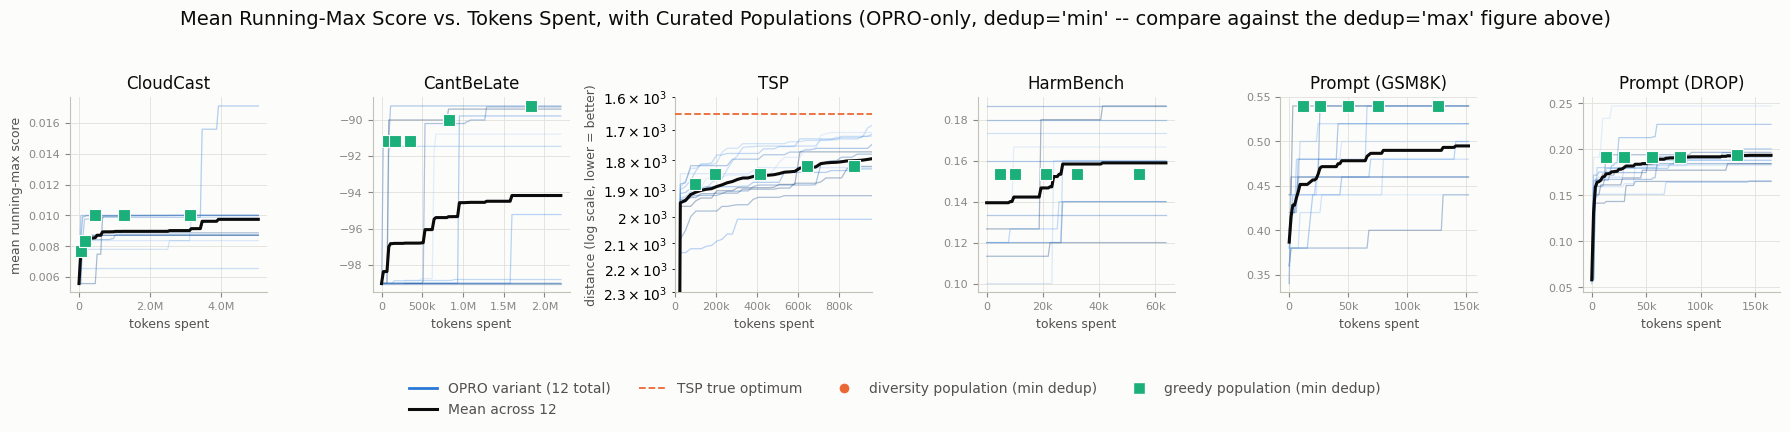

In [22]:
"""Min-dedup companion to the noise=0 score figure (compare against
clean_visual1_row2_opro_only_with_curated_pops.pdf built earlier from the
max-dedup curation_df). Identical plotting logic to that cell -- only the
data source (curation_df_min_dedup) and output filename differ.
"""

TSP_POP_XLIM_MIN_DEDUP = (
    0,
    float(
        curation_df_min_dedup.loc[
            curation_df_min_dedup['task'] == 'TSP', 'token_cost',
        ].max(),
    ) * 1.1,
)

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)

    variants = runs_by_column.get(column_key, {})
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)
    if not variants:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    trajectories = {
        label: (
            np.array([r['cumulative_tokens_spent'] for r in records], dtype=float),
            running_max(np.array([r['score'] for r in records], dtype=float)),
        )
        for label, records in variants.items()
    }

    grid_end = max(tokens.max() for tokens, _ in trajectories.values())
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    sign = -1.0 if column_key == 'tsp' else 1.0

    interpolated = []
    for label, (tokens, cummax) in trajectories.items():
        resampled = step_interpolate(tokens, cummax, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, sign * resampled, color=color_for(label), linewidth=0.9,
            alpha=0.35, zorder=2,
        )

    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, sign * mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    scatter_curated_populations(ax, column_key, sign, df=curation_df_min_dedup)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key == 'tsp':
        ax.set_xlim(*TSP_POP_XLIM_MIN_DEDUP)
    elif column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO variant (12 total)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across 12'),
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], marker=CURATION_MARKER[curation_type], color='none',
        markerfacecolor=color, markeredgecolor=SURFACE, markersize=8,
        label=f'{curation_type} population (min dedup)',
    )
    for curation_type, color in CURATION_COLOR.items()
    # only diversity/greedy are actually plotted here (see
    # MIN_DEDUP_CURATION_CONFIGS above) -- skip legend entries for
    # curation types this section never draws.
    if curation_type in curation_df_min_dedup['curation_type'].unique()
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.26),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, with Curated Populations '
    "(OPRO-only, dedup='min' -- compare against the dedup='max' figure above)",
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_only_with_curated_pops_min_dedup.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual1_row2_opro_only_with_curated_pops_min_dedup.pdf")}',
)

plt.show()


saved to ../figs/clean_visual1_row2_opro_by_noise_with_curated_pops_min_dedup.pdf


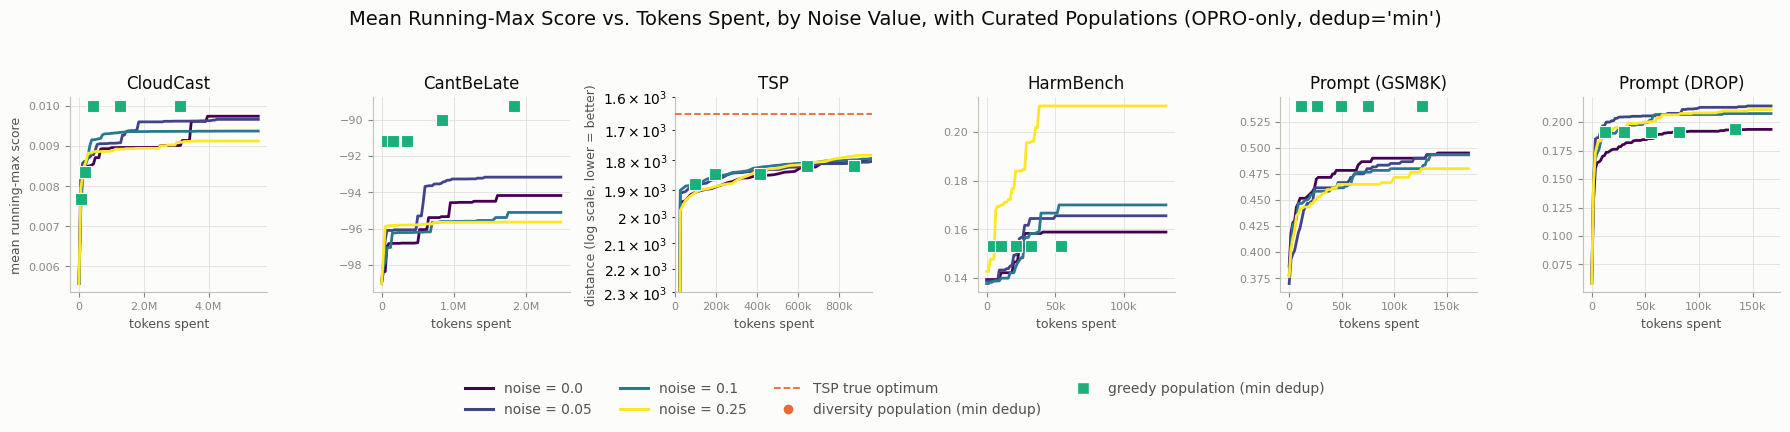

In [23]:
"""Min-dedup companion to the by-noise score figure (compare against
clean_visual1_row2_opro_by_noise_with_curated_pops.pdf built earlier).
Identical plotting logic -- only the data source (curation_df_min_dedup)
and output filename differ. Reuses TSP_POP_XLIM_MIN_DEDUP from the cell
above.
"""

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    by_noise = runs_by_column_noise.get(column_key, {})
    if not by_noise:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    grid_end = max(
        r['cumulative_tokens_spent']
        for variants in by_noise.values()
        for records in variants.values()
        for r in records
    )
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    sign = -1.0 if column_key == 'tsp' else 1.0

    for noise_value in NOISE_VALUES:
        variants = by_noise.get(noise_value)
        if not variants:
            continue
        interpolated = []
        for records in variants.values():
            tokens = np.array(
                [r['cumulative_tokens_spent'] for r in records], dtype=float,
            )
            cummax = running_max(
                np.array([r['score'] for r in records], dtype=float),
            )
            interpolated.append(step_interpolate(tokens, cummax, grid))
        mean_series = np.nanmean(np.vstack(interpolated), axis=0)
        ax.plot(
            grid, sign * mean_series, color=color_for_noise(noise_value),
            linewidth=2.0, zorder=3,
        )

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    scatter_curated_populations(ax, column_key, sign, df=curation_df_min_dedup)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key == 'tsp':
        ax.set_xlim(*TSP_POP_XLIM_MIN_DEDUP)
    elif column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=color_for_noise(n), lw=2.2, label=f'noise = {n}')
    for n in NOISE_VALUES
] + [
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], marker=CURATION_MARKER[curation_type], color='none',
        markerfacecolor=color, markeredgecolor=SURFACE, markersize=8,
        label=f'{curation_type} population (min dedup)',
    )
    for curation_type, color in CURATION_COLOR.items()
    # only diversity/greedy are actually plotted here (see
    # MIN_DEDUP_CURATION_CONFIGS above) -- skip legend entries for
    # curation types this section never draws.
    if curation_type in curation_df_min_dedup['curation_type'].unique()
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.26),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, by Noise Value, with Curated '
    "Populations (OPRO-only, dedup='min')",
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(
        FIGS_DIR, 'clean_visual1_row2_opro_by_noise_with_curated_pops_min_dedup.pdf',
    ),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual1_row2_opro_by_noise_with_curated_pops_min_dedup.pdf")}',
)

plt.show()
